In [44]:
# @title
# ============================================================
# File: 00_setup_folders_colab.py
# Purpose:
#   Create project folder structure inside Google Colab,
#   optionally mounting Google Drive for persistence.
#
# Input:
#   None
# Output:
#   Creates folders under /content/AI_GRC_Project (local)
#   or /content/drive/MyDrive/AI_GRC_Project (Drive-mounted).
# ============================================================

from pathlib import Path
import os

# ------------------------------------------------------------
# Option 1: Use Google Drive for persistence across sessions
# ------------------------------------------------------------
USE_DRIVE = True  # set False if you don't want to mount Drive

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    BASE_DIR = Path("/content/drive/MyDrive/AI_GRC_Project")
else:
    BASE_DIR = Path("/content/AI_GRC_Project")

# ------------------------------------------------------------
# Create folder hierarchy
# ------------------------------------------------------------
FOLDERS = [
    BASE_DIR / "data" / "raw",
    BASE_DIR / "outputs" / "intel_objects",
    BASE_DIR / "outputs" / "logs",
    BASE_DIR / "models",
    BASE_DIR / "config",
]

for folder in FOLDERS:
    folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Set environment variable for downstream cells
# ------------------------------------------------------------
os.environ["PROJECT_ROOT"] = str(BASE_DIR)

print("=== Google Colab Project Setup Complete ===")
print("Project root:", BASE_DIR)
print("Subfolders:")
for f in FOLDERS:
    print(" -", f)

Mounted at /content/drive
=== Google Colab Project Setup Complete ===
Project root: /content/drive/MyDrive/AI_GRC_Project
Subfolders:
 - /content/drive/MyDrive/AI_GRC_Project/data/raw
 - /content/drive/MyDrive/AI_GRC_Project/outputs/intel_objects
 - /content/drive/MyDrive/AI_GRC_Project/outputs/logs
 - /content/drive/MyDrive/AI_GRC_Project/models
 - /content/drive/MyDrive/AI_GRC_Project/config


In [ ]:
# =================================================================================================
# File: 01_data_download_cve.py
#
# PURPOSE:
#   Download raw CVE JSON files for years 1999–2025 using the Espressif NVD mirror.
#
#   Saves all CVE data into the project folder structure:
#       /content/drive/MyDrive/AI_GRC_Project/data/raw/<year>/CVE-YYYY-NNNN.json
#
#   This code does following logic:
#       - Full skip logic if yearly folders already contain data
#       - Skip per-file download if file already exists
# =================================================================================================

import requests
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# =================================================================================================
# PATHS & FOLDERS
# =================================================================================================

BASE_DIR = Path("/content/drive/MyDrive/AI_GRC_Project")

RAW_DATA_DIR = BASE_DIR / "data" / "raw"

FOLDERS = [
    BASE_DIR / "data" / "raw",
    BASE_DIR / "outputs" / "intel_objects",
    BASE_DIR / "outputs" / "logs",
    BASE_DIR / "models",
    BASE_DIR / "config",
]

for f in FOLDERS:
    f.mkdir(parents=True, exist_ok=True)

# =================================================================================================
# CONFIGURATION
# =================================================================================================

YEARS_TO_FETCH = list(range(1999, 2026))

BASE_URL = "https://raw.githubusercontent.com/espressif/esp-nvd-mirror/master/cve"

def get_cves_per_year(year: int) -> int:
    if year >= 2021:
        return 1500
    elif year >= 2010:
        return 500
    else:
        return 100

# =================================================================================================
# DOWNLOADER LOGIC
# =================================================================================================

def download_cve(cve_id: str, year_dir: Path) -> None:
    """
    Download a single CVE JSON file unless it already exists.
    """
    file_path = year_dir / cve_id
    if file_path.exists():
        return  # Skip existing file

    url = f"{BASE_URL}/{year_dir.name}/{cve_id}"

    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            with open(file_path, "wb") as f:
                f.write(response.content)
        elif response.status_code != 404:
            print(f"Warning: skipped {cve_id} (HTTP {response.status_code})")

    except requests.exceptions.RequestException as e:
        print(f"Error fetching {cve_id}: {e}")

# =================================================================================================
# MAIN DOWNLOAD FUNCTION (WITH SKIP LOGIC)
# =================================================================================================

def year_has_data(year_dir: Path) -> bool:
    """
    Returns True if the folder exists and contains at least one JSON file.
    """
    if not year_dir.exists():
        return False
    json_files = list(year_dir.glob("*.json"))
    return len(json_files) > 0


def fetch_cve_data() -> None:
    """
    Download CVE data by year into data/raw with full skip logic.
    """
    print("Checking CVE dataset...")

    RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

    all_years_have_data = True

    # First check if ALL required years already contain files
    for year in YEARS_TO_FETCH:
        year_dir = RAW_DATA_DIR / str(year)
        if not year_has_data(year_dir):
            all_years_have_data = False
            break

    # If all years have data → skip all downloads
    if all_years_have_data:
        print("All CVE data is already available. No download needed.")
        print(f"Raw CVE data located at: {RAW_DATA_DIR}")
        return

    # Otherwise, download year-by-year
    for year in YEARS_TO_FETCH:
        year_dir = RAW_DATA_DIR / str(year)
        year_dir.mkdir(exist_ok=True)

        if year_has_data(year_dir):
            print(f"[SKIP] Year {year}: data already exists.")
            continue

        print(f"\nProcessing CVEs for year {year}...")

        total_cves = get_cves_per_year(year)
        cve_ids = [f"CVE-{year}-{num:04d}.json" for num in range(1, total_cves + 1)]

        with ThreadPoolExecutor(max_workers=20) as executor:
            list(
                tqdm(
                    executor.map(lambda cid: download_cve(cid, year_dir), cve_ids),
                    total=len(cve_ids),
                    desc=f"Downloading {year}",
                )
            )

    print("\nCVE data download completed.")
    print(f"Raw JSON files saved to: {RAW_DATA_DIR}")

# =================================================================================================
# MAIN ENTRYPOINT
# =================================================================================================

if __name__ == "__main__":
    fetch_cve_data()

Checking CVE dataset...
All CVE data is already available. No download needed.
Raw CVE data located at: /content/drive/MyDrive/AI_GRC_Project/data/raw


=== Loading SBERT model (GPU-accelerated) ===
SBERT device: cuda:0
Train/Test size: 9734 3245


Batches:   0%|          | 0/153 [00:00<?, ?it/s]

Batches:   0%|          | 0/51 [00:00<?, ?it/s]


=== MODEL EVALUATION ===
Accuracy: 0.9183359013867488
Macro F1: 0.8906218973316123
Weighted F1: 0.9177989841426921

Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.93      0.93       983
         Low       0.85      0.78      0.81       350
      Medium       0.93      0.94      0.93      1912

    accuracy                           0.92      3245
   macro avg       0.90      0.88      0.89      3245
weighted avg       0.92      0.92      0.92      3245



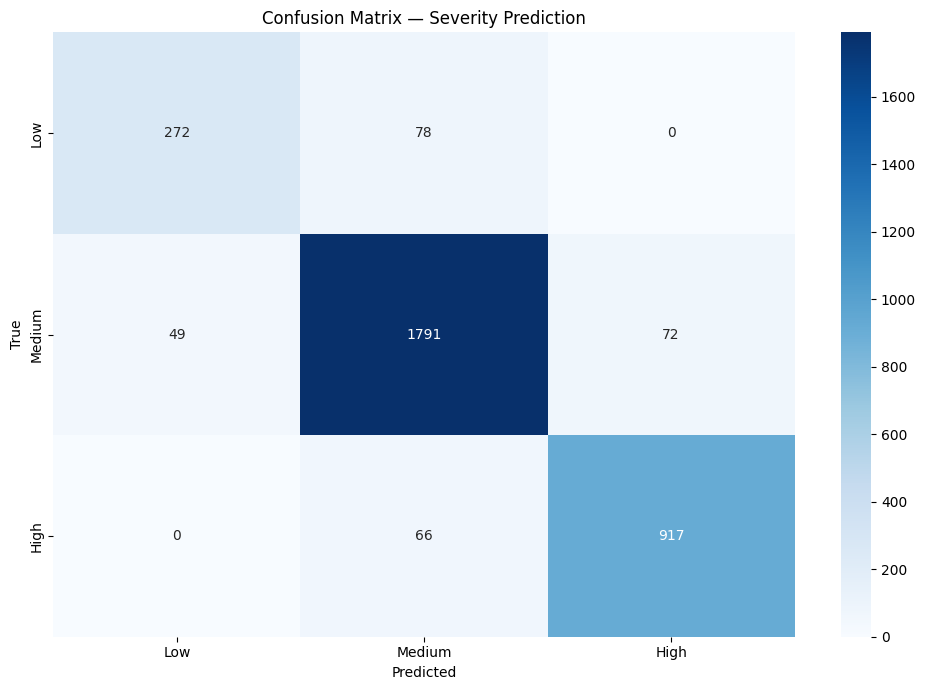


Saved 3245 AI_Risk_Intel records → /content/drive/MyDrive/AI_GRC_Project/outputs/intel_objects/ai_risk_intel_sbert_lgbm_gpu.jsonl


In [46]:
# @title
# =================================================================================================
# File: 01_component1_ai_risk_intel_sbert_LightGBM_gpu.py
# -------------------------------------------------------------------------------------------------
# PURPOSE:
#   Component 1 of the AI-GRC pipeline. This module performs:
#
#   (1) NVD JSON ingestion (1999–2025+) with robust extraction of:
#           • CVE ID
#           • English-language description
#           • CWE identifiers (legacy + modern formats)
#           • CPE URIs (affected products)
#           • Vendor/Product tokens
#           • Published timestamp
#           • CVSS v4.0 / v3.1 / v3.0 / v2 base score
#           • Normalized 8-dimensional CVSS vector (AV, AC, PR/Au, UI, S, C, I, A)
#
#   (2) SBERT text embedding on GPU
#
#   (3) Feature construction:
#           Text embedding  → 768-D
#           CVSS vector     →   8-D
#           Final feature   → 776-D concatenated vector
#
#   (4) Multiclass severity prediction (Low / Medium / High) using:
#           • LightGBM (GPU)
#           • Balanced class weights
#           • Isotonic probability calibration (for evaluation)
#
#   (5) Model evaluation:
#           Confusion matrix + precision, recall, macro/weighted F1
#
#   (6) Intelligence export:
#           AI_Risk_Intel records (severity, distribution, context fields) to JSONL:
#           • intel_id, description, published
#           • cwe_ids, cpe_uris, vendors, products, asset_candidates
#           • cvss_score, cvss_vector
#           • predicted_severity, prediction_distribution
#           • key_influential_features (top semantic concepts)
#
# NOTE:
#   Model training logic is unchanged vs your previous version; only parsing + export are richer.
# =================================================================================================

import os, json, warnings, joblib, nltk, logging, re
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from lightgbm import LGBMClassifier, log_evaluation
from sentence_transformers import SentenceTransformer
from typing import Dict, Any, List

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
os.environ["LIGHTGBM_VERBOSITY"] = "-1"

# =================================================================================================
# CVSS UNIVERSAL NORMALIZATION TABLE
# =================================================================================================

CVSS_MAP = {
    # Vector components (AV / AC / AR / PR / UI / S)
    "NETWORK": 3, "ADJACENT_NETWORK": 2, "ADJACENT": 2, "LOCAL": 1, "PHYSICAL": 0,
    "LOW": 1, "MEDIUM": 2, "HIGH": 3,
    "NONE": 0,
    # User Interaction
    "REQUIRED": 1, "NONE_UI": 0,
    # Scope
    "UNCHANGED": 0, "CHANGED": 1,
    # CIA impact values
    "NONE_IMPACT": 0, "PARTIAL": 1, "LOW_IMPACT": 1, "LOW": 1,
    "HIGH": 2, "COMPLETE": 3,
}


def _cvss_lookup(raw: Any, default_key: str = "NONE_IMPACT") -> int:
    if raw is None:
        return 0
    key = str(raw).upper().replace(" ", "_")
    return CVSS_MAP.get(key, CVSS_MAP.get(default_key, 0))


def encode_cvss_vector_any(cvss_data: dict | None) -> np.ndarray:
    """
    Convert CVSS v4.x / v3.x / v2 dictionary into a fixed 8-dimensional numeric vector:
    [AV, AC, PR/Au, UI, Scope, C, I, A]
    """
    if not cvss_data:
        return np.zeros(8, dtype=np.float32)

    # Attack Vector
    AV = 0
    for k in ["attackVector", "accessVector"]:
        if k in cvss_data:
            AV = _cvss_lookup(cvss_data[k])
            break

    # Attack Complexity
    AC = 0
    for k in ["attackComplexity", "accessComplexity"]:
        if k in cvss_data:
            AC = _cvss_lookup(cvss_data[k])
            break

    # Privileges / Authentication
    PR = 0
    for k in ["privilegesRequired", "authentication", "attackRequirements"]:
        if k in cvss_data:
            PR = _cvss_lookup(cvss_data[k])
            break

    # User Interaction
    UI = 0
    for k in ["userInteraction"]:
        if k in cvss_data:
            UI = _cvss_lookup(cvss_data[k], default_key="NONE_UI")
            break

    # Scope (v3/v4)
    S = 0
    for k in ["scope"]:
        if k in cvss_data:
            S = _cvss_lookup(cvss_data[k])
            break

    # Confidentiality, Integrity, Availability Impact
    C = 0
    I = 0
    A = 0

    for field, key_list in [
        ("confidentialityImpact",
         ["confidentialityImpact", "vulnConfidentialityImpact"]),
        ("integrityImpact",
         ["integrityImpact", "vulnIntegrityImpact"]),
        ("availabilityImpact",
         ["availabilityImpact", "vulnAvailabilityImpact"]),
    ]:
        val = None
        for k in key_list:
            if k in cvss_data:
                val = cvss_data[k]
                break
        if field.startswith("confidentiality"):
            C = _cvss_lookup(val)
        elif field.startswith("integrity"):
            I = _cvss_lookup(val)
        else:
            A = _cvss_lookup(val)

    return np.array([AV, AC, PR, UI, S, C, I, A], dtype=np.float32)


# =================================================================================================
# Environment & Paths
# =================================================================================================

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", "/content/drive/MyDrive/AI_GRC_Project"))
RAW_DIR      = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR   = PROJECT_ROOT / "outputs" / "intel_objects"
LOG_DIR      = PROJECT_ROOT / "outputs" / "logs"
MODEL_DIR    = PROJECT_ROOT / "models"

for d in [OUTPUT_DIR, LOG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=LOG_DIR / "component1_sbert_lightgbm_gpu.log",
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)


# =================================================================================================
# Helpers: CPE & CWE parsing
# =================================================================================================

def parse_cpe_vendor_product(cpe_list: List[str]) -> tuple[list[str], list[str]]:
    vendors, products = [], []
    for c in cpe_list:
        parts = c.split(":")
        if len(parts) >= 5:
            vendors.append(parts[3])
            products.append(parts[4])
    # deduplicate while preserving order
    vendors = list(dict.fromkeys(vendors))
    products = list(dict.fromkeys(products))
    return vendors, products


def extract_cwes(cve: dict, description_text: str) -> list[str]:
    """
    Universal CWE extractor:
      - cve['weaknesses'][*]['description'][*]['value']
      - cve['problemtype']['problemtype_data'][*]['description'][*]['value']
      - fallback: regex "CWE-<digits>" in description
      - normalize "NVD-CWE-noinfo" / "NVD-CWE-Other"
    """
    cwes = []

    # Newer NVD format: weaknesses[]
    for w in cve.get("weaknesses", []):
        for d in w.get("description", []):
            val = d.get("value") or ""
            if not val:
                continue
            if "CWE-" in val:
                m = re.findall(r"CWE-\d+", val)
                cwes.extend(m)
            elif "NVD-CWE-noinfo" in val:
                cwes.append("CWE-000")  # synthetic id
            elif "NVD-CWE-Other" in val:
                cwes.append("CWE-999")

    # Older NVD format: problemtype.problemtype_data
    prob = cve.get("problemtype", {}).get("problemtype_data", [])
    for p in prob:
        for d in p.get("description", []):
            val = d.get("value") or ""
            if "CWE-" in val:
                m = re.findall(r"CWE-\d+", val)
                cwes.extend(m)
            elif "NVD-CWE-noinfo" in val:
                cwes.append("CWE-000")
            elif "NVD-CWE-Other" in val:
                cwes.append("CWE-999")

    # Fallback: search in description text
    if description_text:
        m = re.findall(r"CWE-\d+", description_text)
        cwes.extend(m)

    # Deduplicate
    cwes = list(dict.fromkeys(cwes))
    return cwes


def extract_cpes(configurations: Any) -> list[str]:
    """
    Universal CPE extractor across NVD versions.
    Walks 'nodes' and looks at 'cpeMatch' (new) or 'cpe_match' (older).
    Supports 'criteria' and 'cpe23Uri'.
    """
    cpe_uris = []

    if isinstance(configurations, dict):
        config_list = [configurations]
    elif isinstance(configurations, list):
        config_list = configurations
    else:
        return cpe_uris

    def walk_node(node: dict):
        # new schema: cpeMatch
        for key in ["cpeMatch", "cpe_match"]:
            for m in node.get(key, []):
                if m.get("vulnerable", True):
                    uri = m.get("cpe23Uri") or m.get("criteria") or m.get("cpe22Uri")
                    if uri:
                        cpe_uris.append(uri)
        # children
        for child in node.get("children", []):
            walk_node(child)

    for cfg in config_list:
        for node in cfg.get("nodes", []):
            walk_node(node)

    return list(dict.fromkeys(cpe_uris))


# =================================================================================================
# NVD JSON PARSER (enhanced)
# =================================================================================================

def parse_nvd_json(fp: Path) -> Dict[str, Any] | None:
    """
    Robust NVD parser: handles 25+ years of evolving formats (v2, v3, v4).
    Returns a dictionary with description, CVSS score, CVSS vector, CWE, CPE, etc.
    """
    try:
        with open(fp, "r", encoding="utf-8") as f:
            data = json.load(f)

        # Most NVD files have top-level "cve" object
        cve = data.get("cve", data)

        # --- CVE ID ---
        cve_id = cve.get("id") or data.get("id") or ""

        # --- Description (English) ---
        desc = ""
        for d in cve.get("descriptions", []):
            if d.get("lang", "").lower() == "en":
                desc = d.get("value", "")
                break

        # --- Published timestamp ---
        published = (
            cve.get("published")
            or data.get("published")
            or cve.get("Published")
            or data.get("Published")
            or ""
        )

        # --- Metrics / CVSS ---
        metrics = cve.get("metrics", data.get("metrics", {}))
        cvss_data = None
        cvss_score = 0.0

        # Priority: v4.0 → v3.1 → v3.0 → v2
        metric_priority = [
            "cvssMetricV40",
            "cvssMetricV31",
            "cvssMetricV30",
            "cvssMetricV3",
            "cvssMetricV2",
        ]

        for key in metric_priority:
            if key in metrics and metrics[key]:
                entry = metrics[key][0]
                # v4 and v3 both usually have 'cvssData'
                cvss_data = entry.get("cvssData", {})
                if cvss_data:
                    cvss_score = float(cvss_data.get("baseScore", 0.0))
                break

        cvss_vector = encode_cvss_vector_any(cvss_data)

        # --- CWE IDs ---
        cwe_ids = extract_cwes(cve, desc)

        # --- CPE URIs ---
        configurations = cve.get("configurations", data.get("configurations", []))
        cpe_uris = extract_cpes(configurations)

        # --- Vendor / Products ---
        vendors, products = parse_cpe_vendor_product(cpe_uris)

        return {
            "cve_id": cve_id,
            "description": desc,
            "cvss_score": cvss_score,
            "cvss_vector": cvss_vector,
            "published": published,
            "cwe_ids": cwe_ids,
            "cpe_uris": cpe_uris,
            "vendors": vendors,
            "products": products,
        }

    except Exception as e:
        logging.warning(f"Parse error {fp.name}: {e}")
        return None


# =================================================================================================
# Dataset loader
# =================================================================================================

def load_all_nvd_records(raw_dir: Path, year_range=None, limit=None) -> pd.DataFrame:
    """
    Load and parse CVE records over a directory tree of year folders.
    Expects layout: RAW_DIR / 1999 / CVE-1999-XXXX.json, etc.
    """
    records: list[dict] = []
    dirs = sorted([p for p in raw_dir.iterdir() if p.is_dir()])

    if year_range:
        dirs = [p for p in dirs if p.name.isdigit() and int(p.name) in year_range]

    for d in dirs:
        for f in sorted(d.glob("CVE-*.json")):
            r = parse_nvd_json(f)
            if r:
                records.append(r)
            if limit and len(records) >= limit:
                break
        if limit and len(records) >= limit:
            break

    df = pd.DataFrame(records)
    return df


# =================================================================================================
# Temporal Split (chronological train → test)
# =================================================================================================

def temporal_split(df: pd.DataFrame, test_ratio=0.25):
    """
    Chronologically sorted split to avoid temporal leakage.
    """
    df = df.copy()
    df["published_ts"] = pd.to_datetime(df["published"], errors="coerce", utc=True)
    df = df.sort_values("published_ts").reset_index(drop=True)

    cut = int((1 - test_ratio) * len(df))
    return df.iloc[:cut].copy(), df.iloc[cut:].copy()


# =================================================================================================
# SBERT embedding
# =================================================================================================

print("=== Loading SBERT model (GPU-accelerated) ===")
SBERT_MODEL = "all-MiniLM-L6-v2"

import torch
sbert = SentenceTransformer(
    SBERT_MODEL,
    device="cuda" if torch.cuda.is_available() else "cpu"
)
print("SBERT device:", sbert.device)


def encode_texts(model, texts: list[str]) -> np.ndarray:
    emb = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    return emb.astype(np.float32)


# =================================================================================================
# Feature builder
# =================================================================================================

def build_features(embeddings: np.ndarray, cvss_vectors: np.ndarray | None):
    """Concatenate SBERT embeddings with the 8-D CVSS vector."""
    if cvss_vectors is None:
        return embeddings
    return np.hstack([embeddings, cvss_vectors])


# =================================================================================================
# Concept Bank (semantic similarity)
# =================================================================================================

SECURITY_CONCEPTS = [
    "buffer overflow","heap overflow","integer overflow","memory corruption",
    "race condition","cross site scripting","stored xss","reflected xss",
    "csrf","sql injection","command injection","authentication bypass",
    "authorization bypass","path traversal","directory traversal",
    "open redirect","file inclusion","remote code execution",
    "arbitrary code execution","privilege escalation","denial of service",
    "input validation","insufficient sanitization","improper access control"
]

concept_matrix = sbert.encode(SECURITY_CONCEPTS, normalize_embeddings=True)


def top_concepts(emb, k=5):
    """Retrieve most similar vulnerability concepts."""
    sim = cosine_similarity(emb.reshape(1, -1), concept_matrix).ravel()
    return [SECURITY_CONCEPTS[i] for i in np.argsort(sim)[-k:][::-1]]


# =================================================================================================
# Load, preprocess, split
# =================================================================================================

df = load_all_nvd_records(RAW_DIR, year_range=range(1999, 2026))

df["description"] = df["description"].fillna("")
df["cvss_score"] = df["cvss_score"].fillna(0.0)
df["cvss_vector"] = df["cvss_vector"].apply(lambda v: np.array(v, dtype=np.float32))

# CVSS-based severity bands (unchanged logic)
df["severity_band"] = pd.cut(
    df["cvss_score"],
    [0, 4, 7, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
).astype(str)

train_df, test_df = temporal_split(df)

print("Train/Test size:", len(train_df), len(test_df))


# =================================================================================================
# Encode features
# =================================================================================================

emb_train = encode_texts(sbert, train_df["description"].tolist())
emb_test  = encode_texts(sbert, test_df["description"].tolist())

cvss_train = np.stack(train_df["cvss_vector"].values)
cvss_test  = np.stack(test_df["cvss_vector"].values)

X_train = build_features(emb_train, cvss_train)
X_test  = build_features(emb_test, cvss_test)

y_train, y_test = train_df["severity_band"], test_df["severity_band"]


# =================================================================================================
# Model training (LightGBM GPU) — same logic as before
# =================================================================================================

def train_lgbm(Xtr, ytr, Xv, yv):
    """Train GPU-optimized LightGBM classifier."""
    classes = np.unique(ytr)
    w = compute_class_weight("balanced", classes=classes, y=ytr)
    cw = dict(zip(classes, w))

    model = LGBMClassifier(
        objective="multiclass",
        num_class=len(classes),
        n_estimators=400,
        learning_rate=0.05,
        max_depth=-1,
        n_jobs=-1,
        device_type="gpu" if torch.cuda.is_available() else "cpu",
        class_weight=cw,
        random_state=42,
        verbosity=-1
    )
    model.fit(Xtr, ytr, eval_set=[(Xv, yv)], callbacks=[log_evaluation(0)])
    return model


clf = train_lgbm(X_train, y_train, X_test, y_test)

# Probability calibration (used for evaluation)
from sklearn.calibration import CalibratedClassifierCV
calibrated_model = CalibratedClassifierCV(clf, cv="prefit", method="isotonic")
calibrated_model.fit(X_train, y_train)


# =================================================================================================
# Evaluation
# =================================================================================================

print("\n=== MODEL EVALUATION ===")
y_pred = calibrated_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.title("Confusion Matrix — Severity Prediction")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# =================================================================================================
# AI_Risk_Intel Export (ENHANCED, but same classification logic)
# =================================================================================================

intel_records = []

# We already have emb_test for descriptions; reuse it instead of re-encoding
for emb_vec, (_, r) in zip(emb_test, test_df.iterrows()):
    cv = r["cvss_vector"].reshape(1, -1)
    X = build_features(emb_vec.reshape(1, -1), cv)

    # For continuity with your previous pipeline, use the base clf probabilities
    probs = clf.predict_proba(X)[0]

    intel_records.append({
        "intel_id": r["cve_id"],

        # Context from raw CVE
        "description": r["description"],
        "published": r["published"],
        "cwe_ids": r.get("cwe_ids", []),
        "cpe_uris": r.get("cpe_uris", []),
        "vendors": r.get("vendors", []),
        "products": r.get("products", []),
        "asset_candidates": r.get("products", []),

        # CVSS metrics
        "cvss_score": float(r["cvss_score"]),
        "cvss_vector": r["cvss_vector"].tolist(),

        # Model output
        "predicted_severity": clf.classes_[np.argmax(probs)],
        "prediction_distribution": dict(zip(clf.classes_, probs.round(3).tolist())),
        "key_influential_features": top_concepts(emb_vec),

        # Metadata
        "model_metadata": {
            "model_version": "3.0-SBERT-LightGBM-GPU-CVSS-Vector-UniversalNVD",
            "timestamp": datetime.utcnow().isoformat()
        }
    })


out_path = OUTPUT_DIR / "ai_risk_intel_sbert_lgbm_gpu.jsonl"
with open(out_path, "w", encoding="utf-8") as f:
    for r in intel_records:
        f.write(json.dumps(r) + "\n")

joblib.dump(clf, MODEL_DIR / "sbert_lgbm_gpu.pkl")

print(f"\nSaved {len(intel_records)} AI_Risk_Intel records → {out_path}")


=== Loading SBERT model (GPU-accelerated) ===
SBERT device: cuda:0
Train/Test size: 9734 3245


Batches:   0%|          | 0/153 [00:00<?, ?it/s]

Batches:   0%|          | 0/51 [00:00<?, ?it/s]


=== MODEL EVALUATION ===
Accuracy: 0.9103235747303544
Macro F1: 0.8814660505102244
Weighted F1: 0.9090748463056381

Classification Report:
              precision    recall  f1-score   support

        High       0.92      0.91      0.91       983
         Low       0.90      0.73      0.80       350
      Medium       0.91      0.94      0.93      1912

    accuracy                           0.91      3245
   macro avg       0.91      0.86      0.88      3245
weighted avg       0.91      0.91      0.91      3245



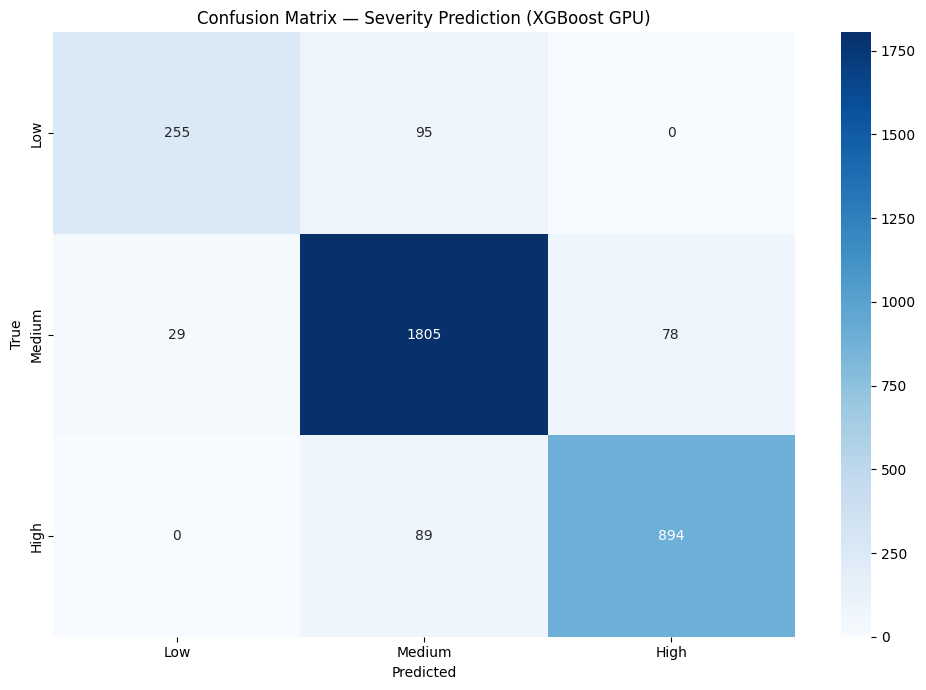


Saved 3245 AI_Risk_Intel records → /content/drive/MyDrive/AI_GRC_Project/outputs/intel_objects/ai_risk_intel_sbert_xgb_gpu.jsonl


In [ ]:
# @title
# =================================================================================================
# File: 01_component1_ai_risk_intel_sbert_XGBoost_gpu.py
# -------------------------------------------------------------------------------------------------
# PURPOSE:
#   Component 1 of the AI-GRC pipeline. This module performs:
#
#   (1) NVD JSON ingestion (1999–2025+) with robust extraction of:
#           • CVE ID
#           • English-language description
#           • CWE identifiers (legacy + modern formats)
#           • CPE URIs (affected products)
#           • Vendor/Product tokens
#           • Published timestamp
#           • CVSS v4.0 / v3.1 / v3.0 / v2 base score
#           • Normalized 8-dimensional CVSS vector (AV, AC, PR/Au, UI, S, C, I, A)
#
#   (2) SBERT text embedding on GPU
#
#   (3) Feature construction:
#           Text embedding  → 768-D
#           CVSS vector     →   8-D
#           Final feature   → 776-D concatenated vector
#
#   (4) Multiclass severity prediction (Low / Medium / High) using:
#           • XGBoost (GPU)
#           • Balanced class weights (via sample_weight)
#           • Isotonic probability calibration (for evaluation)
#
#   (5) Model evaluation:
#           Confusion matrix + precision, recall, macro/weighted F1
#
#   (6) Intelligence export:
#           AI_Risk_Intel records (severity, distribution, context fields) to JSONL:
#           • intel_id, description, published
#           • cwe_ids, cpe_uris, vendors, products, asset_candidates
#           • cvss_score, cvss_vector
#           • predicted_severity, prediction_distribution
#           • key_influential_features (top semantic concepts)
#
# NOTE:
#   Same parsing + export as the LightGBM version; only the classifier is XGBoost.
# =================================================================================================

import os, json, warnings, joblib, nltk, logging, re
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.calibration import CalibratedClassifierCV

from sentence_transformers import SentenceTransformer
from typing import Dict, Any, List

import matplotlib.pyplot as plt
import seaborn as sns

# ---- XGBoost instead of LightGBM ----
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =================================================================================================
# CVSS UNIVERSAL NORMALIZATION TABLE
# =================================================================================================

CVSS_MAP = {
    # Vector components (AV / AC / AR / PR / UI / S)
    "NETWORK": 3, "ADJACENT_NETWORK": 2, "ADJACENT": 2, "LOCAL": 1, "PHYSICAL": 0,
    "LOW": 1, "MEDIUM": 2, "HIGH": 3,
    "NONE": 0,
    # User Interaction
    "REQUIRED": 1, "NONE_UI": 0,
    # Scope
    "UNCHANGED": 0, "CHANGED": 1,
    # CIA impact values
    "NONE_IMPACT": 0, "PARTIAL": 1, "LOW_IMPACT": 1, "LOW": 1,
    "HIGH": 2, "COMPLETE": 3,
}


def _cvss_lookup(raw: Any, default_key: str = "NONE_IMPACT") -> int:
    if raw is None:
        return 0
    key = str(raw).upper().replace(" ", "_")
    return CVSS_MAP.get(key, CVSS_MAP.get(default_key, 0))


def encode_cvss_vector_any(cvss_data: dict | None) -> np.ndarray:
    """
    Convert CVSS v4.x / v3.x / v2 dictionary into a fixed 8-dimensional numeric vector:
    [AV, AC, PR/Au, UI, Scope, C, I, A]
    """
    if not cvss_data:
        return np.zeros(8, dtype=np.float32)

    # Attack Vector
    AV = 0
    for k in ["attackVector", "accessVector"]:
        if k in cvss_data:
            AV = _cvss_lookup(cvss_data[k])
            break

    # Attack Complexity
    AC = 0
    for k in ["attackComplexity", "accessComplexity"]:
        if k in cvss_data:
            AC = _cvss_lookup(cvss_data[k])
            break

    # Privileges / Authentication / Attack Requirements
    PR = 0
    for k in ["privilegesRequired", "authentication", "attackRequirements"]:
        if k in cvss_data:
            PR = _cvss_lookup(cvss_data[k])
            break

    # User Interaction
    UI = 0
    for k in ["userInteraction"]:
        if k in cvss_data:
            UI = _cvss_lookup(cvss_data[k], default_key="NONE_UI")
            break

    # Scope (v3/v4)
    S = 0
    for k in ["scope"]:
        if k in cvss_data:
            S = _cvss_lookup(cvss_data[k])
            break

    # Confidentiality, Integrity, Availability Impact
    C = 0
    I = 0
    A = 0

    for field, key_list in [
        ("confidentialityImpact",
         ["confidentialityImpact", "vulnConfidentialityImpact"]),
        ("integrityImpact",
         ["integrityImpact", "vulnIntegrityImpact"]),
        ("availabilityImpact",
         ["availabilityImpact", "vulnAvailabilityImpact"]),
    ]:
        val = None
        for k in key_list:
            if k in cvss_data:
                val = cvss_data[k]
                break
        if field.startswith("confidentiality"):
            C = _cvss_lookup(val)
        elif field.startswith("integrity"):
            I = _cvss_lookup(val)
        else:
            A = _cvss_lookup(val)

    return np.array([AV, AC, PR, UI, S, C, I, A], dtype=np.float32)


# =================================================================================================
# Environment & Paths
# =================================================================================================

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", "/content/drive/MyDrive/AI_GRC_Project"))
RAW_DIR      = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR   = PROJECT_ROOT / "outputs" / "intel_objects"
LOG_DIR      = PROJECT_ROOT / "outputs" / "logs"
MODEL_DIR    = PROJECT_ROOT / "models"

for d in [OUTPUT_DIR, LOG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=LOG_DIR / "component1_sbert_xgboost_gpu.log",
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)


# =================================================================================================
# Helpers: CPE & CWE parsing
# =================================================================================================

def parse_cpe_vendor_product(cpe_list: List[str]) -> tuple[list[str], list[str]]:
    vendors, products = [], []
    for c in cpe_list:
        parts = c.split(":")
        if len(parts) >= 5:
            vendors.append(parts[3])
            products.append(parts[4])
    vendors = list(dict.fromkeys(vendors))
    products = list(dict.fromkeys(products))
    return vendors, products


def extract_cwes(cve: dict, description_text: str) -> list[str]:
    """
    Universal CWE extractor:
      - cve['weaknesses'][*]['description'][*]['value']
      - cve['problemtype']['problemtype_data'][*]['description'][*]['value']
      - fallback: regex "CWE-<digits>" in description
      - normalize "NVD-CWE-noinfo" / "NVD-CWE-Other"
    """
    cwes = []

    # Newer NVD format: weaknesses[]
    for w in cve.get("weaknesses", []):
        for d in w.get("description", []):
            val = d.get("value") or ""
            if not val:
                continue
            if "CWE-" in val:
                m = re.findall(r"CWE-\d+", val)
                cwes.extend(m)
            elif "NVD-CWE-noinfo" in val:
                cwes.append("CWE-000")
            elif "NVD-CWE-Other" in val:
                cwes.append("CWE-999")

    # Older NVD format: problemtype.problemtype_data
    prob = cve.get("problemtype", {}).get("problemtype_data", [])
    for p in prob:
        for d in p.get("description", []):
            val = d.get("value") or ""
            if "CWE-" in val:
                m = re.findall(r"CWE-\d+", val)
                cwes.extend(m)
            elif "NVD-CWE-noinfo" in val:
                cwes.append("CWE-000")
            elif "NVD-CWE-Other" in val:
                cwes.append("CWE-999")

    # Fallback: search in description text
    if description_text:
        m = re.findall(r"CWE-\d+", description_text)
        cwes.extend(m)

    cwes = list(dict.fromkeys(cwes))
    return cwes


def extract_cpes(configurations: Any) -> list[str]:
    """
    Universal CPE extractor across NVD versions.
    Walks 'nodes' and looks at 'cpeMatch' (new) or 'cpe_match' (older).
    Supports 'criteria' and 'cpe23Uri'.
    """
    cpe_uris = []

    if isinstance(configurations, dict):
        config_list = [configurations]
    elif isinstance(configurations, list):
        config_list = configurations
    else:
        return cpe_uris

    def walk_node(node: dict):
        for key in ["cpeMatch", "cpe_match"]:
            for m in node.get(key, []):
                if m.get("vulnerable", True):
                    uri = m.get("cpe23Uri") or m.get("criteria") or m.get("cpe22Uri")
                    if uri:
                        cpe_uris.append(uri)
        for child in node.get("children", []):
            walk_node(child)

    for cfg in config_list:
        for node in cfg.get("nodes", []):
            walk_node(node)

    return list(dict.fromkeys(cpe_uris))


# =================================================================================================
# NVD JSON PARSER (enhanced)
# =================================================================================================

def parse_nvd_json(fp: Path) -> Dict[str, Any] | None:
    """
    Robust NVD parser: handles 25+ years of evolving formats (v2, v3, v4).
    Returns a dictionary with description, CVSS score, CVSS vector, CWE, CPE, etc.
    """
    try:
        with open(fp, "r", encoding="utf-8") as f:
            data = json.load(f)

        # Most NVD files have top-level "cve" object
        cve = data.get("cve", data)

        # --- CVE ID ---
        cve_id = cve.get("id") or data.get("id") or ""

        # --- Description (English) ---
        desc = ""
        for d in cve.get("descriptions", []):
            if d.get("lang", "").lower() == "en":
                desc = d.get("value", "")
                break

        # --- Published timestamp ---
        published = (
            cve.get("published")
            or data.get("published")
            or cve.get("Published")
            or data.get("Published")
            or ""
        )

        # --- Metrics / CVSS ---
        metrics = cve.get("metrics", data.get("metrics", {}))
        cvss_data = None
        cvss_score = 0.0

        # Priority: v4.0 → v3.1 → v3.0 → v3 → v2
        metric_priority = [
            "cvssMetricV40",
            "cvssMetricV31",
            "cvssMetricV30",
            "cvssMetricV3",
            "cvssMetricV2",
        ]

        for key in metric_priority:
            if key in metrics and metrics[key]:
                entry = metrics[key][0]
                cvss_data = entry.get("cvssData", {})
                if cvss_data:
                    cvss_score = float(cvss_data.get("baseScore", 0.0))
                break

        cvss_vector = encode_cvss_vector_any(cvss_data)

        # --- CWE IDs ---
        cwe_ids = extract_cwes(cve, desc)

        # --- CPE URIs ---
        configurations = cve.get("configurations", data.get("configurations", []))
        cpe_uris = extract_cpes(configurations)

        # --- Vendor / Products ---
        vendors, products = parse_cpe_vendor_product(cpe_uris)

        return {
            "cve_id": cve_id,
            "description": desc,
            "cvss_score": cvss_score,
            "cvss_vector": cvss_vector,
            "published": published,
            "cwe_ids": cwe_ids,
            "cpe_uris": cpe_uris,
            "vendors": vendors,
            "products": products,
        }

    except Exception as e:
        logging.warning(f"Parse error {fp.name}: {e}")
        return None


# =================================================================================================
# Dataset loader
# =================================================================================================

def load_all_nvd_records(raw_dir: Path, year_range=None, limit=None) -> pd.DataFrame:
    """
    Load and parse CVE records over a directory tree of year folders.
    Expects layout: RAW_DIR / 1999 / CVE-1999-XXXX.json, etc.
    """
    records: list[dict] = []
    dirs = sorted([p for p in raw_dir.iterdir() if p.is_dir()])

    if year_range:
        dirs = [p for p in dirs if p.name.isdigit() and int(p.name) in year_range]

    for d in dirs:
        for f in sorted(d.glob("CVE-*.json")):
            r = parse_nvd_json(f)
            if r:
                records.append(r)
            if limit and len(records) >= limit:
                break
        if limit and len(records) >= limit:
            break

    df = pd.DataFrame(records)
    return df


# =================================================================================================
# Temporal Split (chronological train → test)
# =================================================================================================

def temporal_split(df: pd.DataFrame, test_ratio=0.25):
    """
    Chronologically sorted split to avoid temporal leakage.
    """
    df = df.copy()
    df["published_ts"] = pd.to_datetime(df["published"], errors="coerce", utc=True)
    df = df.sort_values("published_ts").reset_index(drop=True)

    cut = int((1 - test_ratio) * len(df))
    return df.iloc[:cut].copy(), df.iloc[cut:].copy()


# =================================================================================================
# SBERT embedding
# =================================================================================================

print("=== Loading SBERT model (GPU-accelerated) ===")
SBERT_MODEL = "all-MiniLM-L6-v2"

import torch
sbert = SentenceTransformer(
    SBERT_MODEL,
    device="cuda" if torch.cuda.is_available() else "cpu"
)
print("SBERT device:", sbert.device)


def encode_texts(model, texts: list[str]) -> np.ndarray:
    emb = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    return emb.astype(np.float32)


# =================================================================================================
# Feature builder
# =================================================================================================

def build_features(embeddings: np.ndarray, cvss_vectors: np.ndarray | None):
    """Concatenate SBERT embeddings with the 8-D CVSS vector."""
    if cvss_vectors is None:
        return embeddings
    return np.hstack([embeddings, cvss_vectors])


# =================================================================================================
# Concept Bank (semantic similarity)
# =================================================================================================

SECURITY_CONCEPTS = [
    "buffer overflow","heap overflow","integer overflow","memory corruption",
    "race condition","cross site scripting","stored xss","reflected xss",
    "csrf","sql injection","command injection","authentication bypass",
    "authorization bypass","path traversal","directory traversal",
    "open redirect","file inclusion","remote code execution",
    "arbitrary code execution","privilege escalation","denial of service",
    "input validation","insufficient sanitization","improper access control"
]

concept_matrix = sbert.encode(SECURITY_CONCEPTS, normalize_embeddings=True)


def top_concepts(emb, k=5):
    """Retrieve most similar vulnerability concepts."""
    sim = cosine_similarity(emb.reshape(1, -1), concept_matrix).ravel()
    return [SECURITY_CONCEPTS[i] for i in np.argsort(sim)[-k:][::-1]]


# =================================================================================================
# Load, preprocess, split
# =================================================================================================

df = load_all_nvd_records(RAW_DIR, year_range=range(1999, 2026))

df["description"] = df["description"].fillna("")
df["cvss_score"] = df["cvss_score"].fillna(0.0)
df["cvss_vector"] = df["cvss_vector"].apply(lambda v: np.array(v, dtype=np.float32))

# CVSS-based severity bands (unchanged logic)
df["severity_band"] = pd.cut(
    df["cvss_score"],
    [0, 4, 7, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
).astype(str)

train_df, test_df = temporal_split(df)

print("Train/Test size:", len(train_df), len(test_df))


# =================================================================================================
# Encode features
# =================================================================================================

emb_train = encode_texts(sbert, train_df["description"].tolist())
emb_test  = encode_texts(sbert, test_df["description"].tolist())

cvss_train = np.stack(train_df["cvss_vector"].values)
cvss_test  = np.stack(test_df["cvss_vector"].values)

X_train = build_features(emb_train, cvss_train)
X_test  = build_features(emb_test, cvss_test)

y_train, y_test = train_df["severity_band"], test_df["severity_band"]


# =================================================================================================
# Model training (XGBoost GPU)
# =================================================================================================

def train_xgb(Xtr, ytr, Xv, yv):
    """
    Train GPU-optimized XGBoost classifier.
    Uses integer-encoded labels internally, but preserves string labels externally.
    """
    classes = np.unique(ytr)
    w = compute_class_weight("balanced", classes=classes, y=ytr)
    class_weights = dict(zip(classes, w))

    # Map string labels → integers
    class_to_idx = {c: i for i, c in enumerate(classes)}
    ytr_int = np.array([class_to_idx[c] for c in ytr])
    yv_int  = np.array([class_to_idx[c] for c in yv])

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(classes),
        n_estimators=400,
        learning_rate=0.05,
        max_depth=0,           # 0 → unrestricted depth in newer XGB
        tree_method="hist",    # with device="cuda" this is GPU-accelerated
        device="cuda" if torch.cuda.is_available() else "cpu",
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=42
    )

    sample_weights = np.array([class_weights[c] for c in ytr])

    model.fit(
        Xtr,
        ytr_int,
        sample_weight=sample_weights,
        eval_set=[(Xv, yv_int)],
        verbose=False
    )

    # store mapping for later use (evaluation + export)
    model._custom_classes = classes
    model._class_to_idx = class_to_idx

    return model


clf = train_xgb(X_train, y_train, X_test, y_test)


# =================================================================================================
# Probability calibration (isotonic, for evaluation)
# =================================================================================================

calibrated_model = CalibratedClassifierCV(clf, cv="prefit", method="isotonic")

# Use the same integer encoding as the base model was trained on
y_train_int_for_calib = np.array([clf._class_to_idx[c] for c in y_train])
calibrated_model.fit(X_train, y_train_int_for_calib)


# =================================================================================================
# Evaluation
# =================================================================================================

print("\n=== MODEL EVALUATION ===")

# Calibrated predictions are integers (0..K-1); map back to class labels
idx_to_class = {i: c for i, c in enumerate(clf._custom_classes)}
y_pred_raw = calibrated_model.predict(X_test)
y_pred = np.array([idx_to_class[int(i)] for i in y_pred_raw])

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.title("Confusion Matrix — Severity Prediction (XGBoost GPU)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# =================================================================================================
# AI_Risk_Intel Export (ENHANCED, parallel to LightGBM version)
# =================================================================================================

intel_records = []

classes = clf._custom_classes   # string labels in stable order (matching encoding)

# Reuse emb_test instead of re-encoding descriptions
for emb_vec, (_, r) in zip(emb_test, test_df.iterrows()):
    cv = r["cvss_vector"].reshape(1, -1)
    X = build_features(emb_vec.reshape(1, -1), cv)

    # Use base XGBoost probabilities for continuity with pipeline
    probs = clf.predict_proba(X)[0]

    intel_records.append({
        "intel_id": r["cve_id"],

        # Context from raw CVE
        "description": r["description"],
        "published": r["published"],
        "cwe_ids": r.get("cwe_ids", []),
        "cpe_uris": r.get("cpe_uris", []),
        "vendors": r.get("vendors", []),
        "products": r.get("products", []),
        "asset_candidates": r.get("products", []),

        # CVSS metrics
        "cvss_score": float(r["cvss_score"]),
        "cvss_vector": r["cvss_vector"].tolist(),

        # Model output
        "predicted_severity": classes[np.argmax(probs)],
        "prediction_distribution": dict(zip(classes, probs.round(3).tolist())),
        "key_influential_features": top_concepts(emb_vec),

        # Metadata
        "model_metadata": {
            "model_version": "3.0-SBERT-XGBoost-GPU-CVSS-Vector-UniversalNVD",
            "timestamp": datetime.utcnow().isoformat()
        }
    })

out_path = OUTPUT_DIR / "ai_risk_intel_sbert_xgb_gpu.jsonl"
with open(out_path, "w", encoding="utf-8") as f:
    for r in intel_records:
        f.write(json.dumps(r) + "\n")

joblib.dump(clf, MODEL_DIR / "sbert_xgboost_gpu.pkl")

print(f"\nSaved {len(intel_records)} AI_Risk_Intel records → {out_path}")

=== Loading SBERT model ===
SBERT device: cuda:0
Train/Test: 9734 3245


Batches:   0%|          | 0/153 [00:00<?, ?it/s]

Batches:   0%|          | 0/51 [00:00<?, ?it/s]


=== MODEL EVALUATION (Random Forest) ===
Accuracy: 0.8114021571648691
Macro F1: 0.720887006076024
Weighted F1: 0.7972079556555814

Classification Report:
               precision    recall  f1-score   support

        High       0.90      0.68      0.78       983
         Low       1.00      0.36      0.53       350
      Medium       0.77      0.96      0.86      1912

    accuracy                           0.81      3245
   macro avg       0.89      0.67      0.72      3245
weighted avg       0.84      0.81      0.80      3245



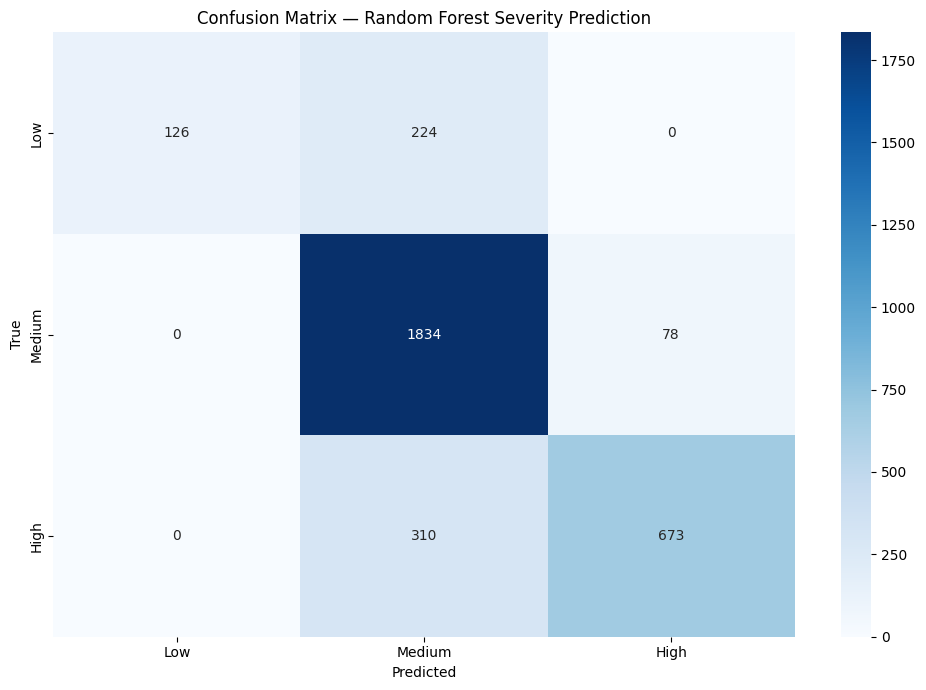


Saved 3245 AI_Risk_Intel records/content/drive/MyDrive/AI_GRC_Project/outputs/intel_objects/ai_risk_intel_sbert_rf.jsonl


In [ ]:
# @title
# =================================================================================================
# File: 01_component1_ai_risk_intel_sbert_RF.py
# -------------------------------------------------------------------------------------------------
# PURPOSE:
#   Component 1 of the AI-GRC pipeline. This module performs:
#
#   (1) NVD JSON ingestion (1999–2025+) with robust extraction of:
#           • CVE ID
#           • English-language description
#           • CWE identifiers (legacy + modern formats)
#           • CPE URIs (affected products)
#           • Vendor/Product tokens
#           • Published timestamp
#           • CVSS v4.0 / v3.1 / v3.0 / v2 base score
#           • Normalized 8-dimensional CVSS vector (AV, AC, PR/Au, UI, S, C, I, A)
#
#   (2) SBERT text embedding on GPU
#
#   (3) Feature construction:
#           Text embedding  → 768-D
#           CVSS vector     →   8-D
#           Final feature   → 776-D concatenated vector
#
#   (4) Multiclass severity prediction (Low / Medium / High) using:
#           • Random Forest (balanced class weights)
#           • Isotonic probability calibration
#
#   (5) Model evaluation:
#           Confusion matrix + precision, recall, macro/weighted F1
#
#   (6) Intelligence export:
#           AI_Risk_Intel records (severity, distribution, context fields) to JSONL:
#           • intel_id, description, published
#           • cwe_ids, cpe_uris, vendors, products, asset_candidates
#           • cvss_score, cvss_vector
#           • predicted_severity, prediction_distribution
#           • key_influential_features (top semantic concepts)
# =================================================================================================

import os, json, warnings, joblib, nltk, logging, re
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.calibration import CalibratedClassifierCV

from sklearn.ensemble import RandomForestClassifier
from sentence_transformers import SentenceTransformer
from typing import Dict, Any, List

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# =================================================================================================
# CVSS UNIVERSAL NORMALIZATION TABLE
# =================================================================================================

CVSS_MAP = {
    "NETWORK": 3, "ADJACENT_NETWORK": 2, "ADJACENT": 2, "LOCAL": 1, "PHYSICAL": 0,
    "LOW": 1, "MEDIUM": 2, "HIGH": 3,
    "NONE": 0,
    "REQUIRED": 1, "NONE_UI": 0,
    "UNCHANGED": 0, "CHANGED": 1,
    "NONE_IMPACT": 0, "PARTIAL": 1, "LOW_IMPACT": 1, "LOW": 1,
    "HIGH": 2, "COMPLETE": 3,
}

def _cvss_lookup(raw: Any, default_key: str = "NONE_IMPACT") -> int:
    if raw is None:
        return 0
    key = str(raw).upper().replace(" ", "_")
    return CVSS_MAP.get(key, CVSS_MAP.get(default_key, 0))

def encode_cvss_vector_any(cvss_data: dict | None) -> np.ndarray:
    if not cvss_data:
        return np.zeros(8, dtype=np.float32)

    AV = 0
    for k in ["attackVector","accessVector"]:
        if k in cvss_data:
            AV = _cvss_lookup(cvss_data[k])
            break

    AC = 0
    for k in ["attackComplexity","accessComplexity"]:
        if k in cvss_data:
            AC = _cvss_lookup(cvss_data[k])
            break

    PR = 0
    for k in ["privilegesRequired","authentication","attackRequirements"]:
        if k in cvss_data:
            PR = _cvss_lookup(cvss_data[k])
            break

    UI = _cvss_lookup(cvss_data.get("userInteraction"), default_key="NONE_UI")

    S = 0
    if "scope" in cvss_data:
        S = _cvss_lookup(cvss_data["scope"])

    C = _cvss_lookup(cvss_data.get("confidentialityImpact"))
    I = _cvss_lookup(cvss_data.get("integrityImpact"))
    A = _cvss_lookup(cvss_data.get("availabilityImpact"))

    return np.array([AV, AC, PR, UI, S, C, I, A], dtype=np.float32)

# =================================================================================================
# Environment Paths
# =================================================================================================

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT","/content/drive/MyDrive/AI_GRC_Project"))
RAW_DIR      = PROJECT_ROOT/"data"/"raw"
OUTPUT_DIR   = PROJECT_ROOT/"outputs"/"intel_objects"
LOG_DIR      = PROJECT_ROOT/"outputs"/"logs"
MODEL_DIR    = PROJECT_ROOT/"models"

for d in [OUTPUT_DIR, LOG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=LOG_DIR/"component1_sbert_rf.log",
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)

# =================================================================================================
# CWE & CPE helpers
# =================================================================================================

def parse_cpe_vendor_product(cpe_list: List[str]):
    vendors, products = [], []
    for c in cpe_list:
        parts = c.split(":")
        if len(parts) >= 5:
            vendors.append(parts[3])
            products.append(parts[4])
    return list(dict.fromkeys(vendors)), list(dict.fromkeys(products))

def extract_cwes(cve: dict, desc: str) -> list[str]:
    cwes = []

    # weaknesses[]
    for w in cve.get("weaknesses", []):
        for d in w.get("description", []):
            val = d.get("value") or ""
            if "CWE-" in val:
                cwes += re.findall(r"CWE-\d+", val)
            elif "NVD-CWE-noinfo" in val:
                cwes.append("CWE-000")
            elif "NVD-CWE-Other" in val:
                cwes.append("CWE-999")

    # problemtype_data[]
    for p in cve.get("problemtype", {}).get("problemtype_data", []):
        for d in p.get("description", []):
            val = d.get("value") or ""
            if "CWE-" in val:
                cwes += re.findall(r"CWE-\d+", val)

    # fallback regex
    cwes += re.findall(r"CWE-\d+", desc)

    return list(dict.fromkeys(cwes))

def extract_cpes(configurations: Any) -> list[str]:
    cpe_uris = []

    if isinstance(configurations, dict):
        configs = [configurations]
    elif isinstance(configurations, list):
        configs = configurations
    else:
        return []

    def walk_node(node):
        for key in ["cpeMatch","cpe_match"]:
            for m in node.get(key, []):
                if m.get("vulnerable", True):
                    uri = m.get("cpe23Uri") or m.get("criteria")
                    if uri: cpe_uris.append(uri)
        for ch in node.get("children", []):
            walk_node(ch)

    for cfg in configs:
        for node in cfg.get("nodes", []):
            walk_node(node)

    return list(dict.fromkeys(cpe_uris))

# =================================================================================================
# NVD JSON PARSER
# =================================================================================================

def parse_nvd_json(fp: Path):
    try:
        with open(fp,"r",encoding="utf-8") as f:
            data = json.load(f)

        cve = data.get("cve", data)
        cve_id = cve.get("id","")

        desc = ""
        for d in cve.get("descriptions",[]):
            if d.get("lang") == "en":
                desc = d.get("value","")
                break

        metrics = cve.get("metrics",{})
        cvss_data = None
        cvss_score = 0.0

        for key in ["cvssMetricV40","cvssMetricV31","cvssMetricV30","cvssMetricV3","cvssMetricV2"]:
            if key in metrics:
                entry = metrics[key][0]
                cvss_data = entry.get("cvssData",{})
                cvss_score = float(cvss_data.get("baseScore",0.0))
                break

        cvss_vector = encode_cvss_vector_any(cvss_data)
        cwe_ids = extract_cwes(cve, desc)

        configurations = cve.get("configurations", data.get("configurations", []))
        cpe_uris = extract_cpes(configurations)
        vendors, products = parse_cpe_vendor_product(cpe_uris)

        published = (cve.get("published") or data.get("published",""))

        return {
            "cve_id": cve_id,
            "description": desc,
            "published": published,
            "cvss_score": cvss_score,
            "cvss_vector": cvss_vector,
            "cwe_ids": cwe_ids,
            "cpe_uris": cpe_uris,
            "vendors": vendors,
            "products": products,
        }

    except Exception as e:
        logging.warning(f"Parse error {fp.name}: {e}")
        return None

# =================================================================================================
# Dataset Loader + Temporal Split
# =================================================================================================

def load_all_nvd_records(raw_dir, year_range=None, limit=None):
    out=[]
    dirs = sorted([p for p in raw_dir.iterdir() if p.is_dir()])
    if year_range:
        dirs = [p for p in dirs if p.name.isdigit() and int(p.name) in year_range]
    for d in dirs:
        for f in sorted(d.glob("CVE-*.json")):
            r=parse_nvd_json(f)
            if r: out.append(r)
            if limit and len(out)>=limit: break
        if limit and len(out)>=limit: break
    return pd.DataFrame(out)

def temporal_split(df, ratio=0.25):
    df=df.copy()
    df["published_ts"]=pd.to_datetime(df["published"],errors="coerce",utc=True)
    df=df.sort_values("published_ts").reset_index(drop=True)
    cut=int((1-ratio)*len(df))
    return df.iloc[:cut], df.iloc[cut:]

# =================================================================================================
# SBERT Embedding
# =================================================================================================

print("=== Loading SBERT model ===")
sbert = SentenceTransformer("all-MiniLM-L6-v2",
                           device="cuda" if torch.cuda.is_available() else "cpu")
print("SBERT device:", sbert.device)

def encode_texts(model, texts):
    return model.encode(texts, batch_size=64, show_progress_bar=True,
                        normalize_embeddings=True).astype(np.float32)

# =================================================================================================
# Feature Builder
# =================================================================================================

def build_features(emb, cv):
    return np.hstack([emb, cv])

# =================================================================================================
# Concept Bank
# =================================================================================================

SECURITY_CONCEPTS = [
    "buffer overflow","heap overflow","integer overflow","memory corruption",
    "race condition","cross site scripting","stored xss","reflected xss",
    "csrf","sql injection","command injection","authentication bypass",
    "authorization bypass","path traversal","directory traversal",
    "open redirect","file inclusion","remote code execution",
    "arbitrary code execution","privilege escalation","denial of service",
    "input validation","insufficient sanitization","improper access control"
]

concept_matrix = sbert.encode(SECURITY_CONCEPTS, normalize_embeddings=True)

def top_concepts(e, k=5):
    sim = cosine_similarity(e.reshape(1,-1), concept_matrix).ravel()
    return [SECURITY_CONCEPTS[i] for i in np.argsort(sim)[-k:][::-1]]

# =================================================================================================
# Load Data → Encode
# =================================================================================================

df = load_all_nvd_records(RAW_DIR, year_range=range(1999,2026))
df["description"]=df["description"].fillna("")
df["cvss_score"]=df["cvss_score"].fillna(0.0)
df["cvss_vector"]=df["cvss_vector"].apply(lambda v: np.array(v,dtype=np.float32))

df["severity_band"] = pd.cut(
    df["cvss_score"], [0,4,7,10],
    labels=["Low","Medium","High"],
    include_lowest=True
).astype(str)

train_df, test_df = temporal_split(df)
print("Train/Test:",len(train_df),len(test_df))

emb_train=encode_texts(sbert,train_df["description"].tolist())
emb_test =encode_texts(sbert,test_df["description"].tolist())

cv_train=np.stack(train_df["cvss_vector"].values)
cv_test =np.stack(test_df["cvss_vector"].values)

X_train = build_features(emb_train,cv_train)
X_test  = build_features(emb_test,cv_test)

y_train,y_test = train_df["severity_band"], test_df["severity_band"]

# =================================================================================================
# RANDOM FOREST TRAINING
# =================================================================================================

def train_rf(Xtr, ytr):
    classes = np.unique(ytr)
    w = compute_class_weight("balanced", classes=classes, y=ytr)
    cw = dict(zip(classes, w))

    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight=cw,
        n_jobs=-1,
        random_state=42,
    )
    model.fit(Xtr, ytr)
    return model

clf = train_rf(X_train, y_train)

# =================================================================================================
# Calibration
# =================================================================================================

calibrated_model = CalibratedClassifierCV(clf, cv="prefit", method="isotonic")
calibrated_model.fit(X_train, y_train)

# =================================================================================================
# Evaluation
# =================================================================================================

print("\n=== MODEL EVALUATION (Random Forest) ===")
y_pred = calibrated_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Macro F1:", f1_score(y_test,y_pred,average="macro"))
print("Weighted F1:", f1_score(y_test,y_pred,average="weighted"))
print("\nClassification Report:\n", classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred,labels=["Low","Medium","High"])
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])
plt.title("Confusion Matrix — Random Forest Severity Prediction")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# =================================================================================================
# AI_Risk_Intel Export
# =================================================================================================

intel_records=[]

for emb_vec,(_,r) in zip(emb_test, test_df.iterrows()):
    cv=r["cvss_vector"].reshape(1,-1)
    X=build_features(emb_vec.reshape(1,-1),cv)
    probs=clf.predict_proba(X)[0]

    intel_records.append({
        "intel_id": r["cve_id"],
        "description": r["description"],
        "published": r["published"],
        "cwe_ids": r.get("cwe_ids",[]),
        "cpe_uris": r.get("cpe_uris",[]),
        "vendors": r.get("vendors",[]),
        "products": r.get("products",[]),
        "asset_candidates": r.get("products",[]),

        "cvss_score": float(r["cvss_score"]),
        "cvss_vector": r["cvss_vector"].tolist(),

        "predicted_severity": clf.classes_[np.argmax(probs)],
        "prediction_distribution": dict(zip(clf.classes_, probs.round(3).tolist())),
        "key_influential_features": top_concepts(emb_vec),

        "model_metadata": {
            "model_version": "3.0-SBERT-RF-CVSS-Vector-UniversalNVD",
            "timestamp": datetime.utcnow().isoformat()
        }
    })

out_path = OUTPUT_DIR/"ai_risk_intel_sbert_rf.jsonl"
with open(out_path,"w",encoding="utf-8") as f:
    for r in intel_records:
        f.write(json.dumps(r)+"\n")

joblib.dump(clf, MODEL_DIR/"sbert_rf_gpu.pkl")

print(f"\nSaved {len(intel_records)} AI_Risk_Intel records{out_path}")

In [ ]:
#@title
# =================================================================================================
# File: 02_component2_policy_alignment.py
#
# PURPOSE:
#   Component 2 — Policy Alignment, Asset-Aware Mapping, and Governance Decisioning (v6)
#
#   Inputs:
#       1) AI_Risk_Intel JSONL from Component 1:
#            - intel_id, description, published
#            - cwe_ids, cpe_uris, vendors, products, asset_candidates
#            - cvss_score, cvss_vector
#            - predicted_severity, prediction_distribution
#            - key_influential_features
#
#       2) Enterprise Controls & Policy Ruleset (enterprise_controls.json):
#            - policy.composite_weighting
#            - policy.slas_by_severity
#            - policy.requires_human_thresholds
#            - controls[] with:
#                  control_id, implementation_status, effectiveness_rating, owner, evidence
#
#       3) Asset Criticality Catalog (asset_criticality.json):
#            - assets[] with:
#                  asset_id, asset_name, criticality, platform,
#                  cpe_candidates[], tags, etc.
#
#       4) NIST SP 800-53 rev5 Catalog:
#            - groups[].controls[].id, title, parts[name/prose]
#
#   Outputs:
#       - outputs/intel_objects/governance_action_packets.jsonl
#       - outputs/intel_objects/governance_action_packets.csv
#       - outputs/reports/governance_enterprise_summary.html
#
#   High-level behavior:
#       • Interpret AI_Risk_Intel as governance decision candidates.
#       • Use CWE + description tokens + policy weights → candidate NIST controls.
#       • Use CPE URIs → match to enterprise assets → per-CVE asset_weight.
#       • Score each control with composite score (keywords, family, CWE, CPE, severity, confidence, asset_weight).
#       • Compute proactive risk_signal and posture (Compliant / At Risk / Non-Compliant).
#       • Decide if human review is required (requires_human).
#       • Emit Governance_Action_Packets with:
#             recommended_action, explanation, matched_assets, controls, referenced_frameworks.
from __future__ import annotations

import os
import re
import json
import csv
import logging
from pathlib import Path
from datetime import datetime
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd

# =================================================================================================
# PATHS & LOGGING
# =================================================================================================

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", "/content/drive/MyDrive/AI_GRC_Project"))

PATH_INTEL   = PROJECT_ROOT / "outputs" / "intel_objects"
PATH_NIST    = PROJECT_ROOT / "config" / "NIST_SP-800-53_rev5_catalog_load.csv"
PATH_CTRL    = PROJECT_ROOT / "config" / "enterprise_controls.json"
PATH_ASSETS  = PROJECT_ROOT / "config" / "asset_criticality.json"

DIR_OUTPUT   = PROJECT_ROOT / "outputs" / "intel_objects"
DIR_REPORTS  = PROJECT_ROOT / "outputs" / "reports"
DIR_LOGS     = PROJECT_ROOT / "outputs" / "logs"

for d in (DIR_OUTPUT, DIR_REPORTS, DIR_LOGS):
    d.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=str(DIR_LOGS / "component2_policy_alignment.log"),
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("component2")

# =================================================================================================
# SMALL HELPERS
# =================================================================================================

def tok(s: str) -> List[str]:
    """Simple alphanumeric tokenizer."""
    return re.sub(r"[^a-z0-9]+", " ", str(s).lower()).split()


def parse_cpe_vendor_product(cpe: str) -> Tuple[str, str]:
    """
    Parse CPE 2.3 URI into (vendor, product).
    Example: cpe:2.3:a:apache:http_server:2.4.57:*:*:*:*:*:*:*  →  ("apache","http_server")
    """
    parts = cpe.split(":")
    if len(parts) >= 5:
        return parts[3].lower(), parts[4].lower()
    return "", ""

# =================================================================================================
# CWE → NIST FAMILY HINTS & HARDCODED OVERRIDES
# =================================================================================================

CWE_TO_NIST_FAMILY = {
    "CWE-79":  ["SI", "SC"],         # XSS
    "CWE-89":  ["SI", "RA"],         # SQLi
    "CWE-352": ["AC", "IA", "SI"],   # CSRF
    "CWE-287": ["IA", "AC"],         # Auth bypass
    "CWE-285": ["AC"],               # AuthZ
    "CWE-22":  ["SC", "SI"],         # Path traversal
    "CWE-78":  ["SI", "RA"],         # Command injection
    "CWE-119": ["SI", "RA"],         # Memory corruption
    "CWE-200": ["SC", "SI"],         # Information disclosure
    "CWE-269": ["AC", "IA"],         # Privilege escalation
}

# Hardcoded CWE → NIST control overrides (strong priors, regardless of keyword overlap).
HARDCODED_CWE_TO_NIST = {
    "CWE-79":  ["SI-10", "SC-7", "RA-5"],  # XSS → input validation, boundary protection, vuln mgmt
    "CWE-89":  ["SI-10", "SA-11", "RA-5"], # SQLi → validation, SDLC testing, vuln mgmt
    "CWE-78":  ["SI-10", "SC-7", "RA-5"],  # OS command injection
    "CWE-22":  ["SC-7", "SI-10"],          # path traversal → boundary + validation
    "CWE-287": ["IA-2", "AC-2", "AC-6"],   # auth bypass
    "CWE-285": ["AC-2", "AC-6"],           # authorization
    "CWE-269": ["AC-6", "IA-2"],           # privilege escalation / least privilege
    "CWE-200": ["SC-28", "SC-7"],          # info exposure → data at rest + boundary
}

# =================================================================================================
# LOADERS
# =================================================================================================

def load_latest_intel() -> List[Dict[str, Any]]:
    """Load the newest ai_risk_intel_*.jsonl file from outputs."""
    candidates = sorted(PATH_INTEL.glob("ai_risk_intel_sbert_lgbm*.jsonl"))
    if not candidates:
        raise FileNotFoundError("No ai_risk_intel_*.jsonl found in outputs/intel_objects/")
    latest = max(candidates, key=lambda p: p.stat().st_mtime)
    rows = []
    with latest.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                logger.warning(f"Skipping malformed JSONL line in {latest.name}: {e}")
    print(f"Loaded {len(rows)} AI_Risk_Intel from {latest.name}")
    return rows


def load_enterprise_policy(path: Path) -> Tuple[Dict[str, Any], Dict[str, Dict[str, Any]]]:
    """Load enterprise_controls.json and return (policy, controls_by_id)."""
    if not path.exists():
        raise FileNotFoundError(f"enterprise_controls.json not found at {path}")
    data = json.loads(path.read_text(encoding="utf-8"))
    policy = data.get("policy", {})
    controls = {c["control_id"]: c for c in data.get("controls", []) if "control_id" in c}
    return policy, controls


def load_assets(path: Path) -> Dict[str, Dict[str, Any]]:
    """Load asset_criticality.json (Option B1, grouped assets)."""
    if not path.exists():
        raise FileNotFoundError(f"asset_criticality.json not found at {path}")
    data = json.loads(path.read_text(encoding="utf-8"))
    assets = {}
    for a in data.get("assets", []):
        aid = a.get("asset_id")
        if not aid:
            continue
        # normalize fields
        a.setdefault("criticality", 0.7)
        a.setdefault("cpe_candidates", [])
        a.setdefault("tags", [])
        a.setdefault("data_classification", "Internal")
        a.setdefault("mitre_exposure", [])
        assets[aid] = a
    print(f"Loaded {len(assets)} enterprise assets from {path.name}")
    return assets


def load_nist_catalog(path: Path) -> pd.DataFrame:
    """
    Load NIST SP-800-53 Rev5 controls from CSV only.
    This CSV MUST contain:
        identifier, name, control_text, discussion, related
    """

    if not path.exists():
        raise FileNotFoundError(f"NIST CSV not found: {path}")

    df = pd.read_csv(path)

    # Required columns
    required = ["identifier", "name", "control_text", "discussion", "related"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"NIST CSV missing required columns: {missing}")

    # Normalize string fields
    def norm(s):
        return re.sub(r"[^a-z0-9]+", " ", str(s).lower()).strip()

    # Build lexical search blob
    df["blob"] = (
        df["identifier"].map(norm) + " " +
        df["name"].map(norm) + " " +
        df["control_text"].map(norm) + " " +
        df["discussion"].map(norm)
    )

    # Extract NIST control family (AC, AU, IA, CM, etc.)
    df["family"] = df["identifier"].str.extract(r"^([A-Z]{2})", expand=False).fillna("")

    print(f"NIST catalog loaded (CSV): {len(df)} controls")
    return df

# =================================================================================================
# ASSET CPE INDEX & MATCHING (STRENGTHENED WITH TAGS + MITRE)
# =================================================================================================

def build_asset_cpe_index(assets: Dict[str, Dict[str, Any]]) -> Dict[str, List[Tuple[str, str]]]:
    """
    Build an index: asset_id -> [(vendor, product), ...] from asset cpe_candidates.
    """
    index: Dict[str, List[Tuple[str, str]]] = {}
    for aid, a in assets.items():
        pairs = []
        for c in a.get("cpe_candidates", []):
            v, p = parse_cpe_vendor_product(c)
            if not v:
                continue
            pairs.append((v, p))
        # dedupe
        pairs = list(dict.fromkeys(pairs))
        index[aid] = pairs
    return index


def cpe_pair_match(intel_pair: Tuple[str, str], asset_pair: Tuple[str, str]) -> bool:
    """
    Matching logic between intel CPE (v_i, p_i) and asset CPE (v_a, p_a):
      - vendor must match exactly (case-insensitive)
      - product matches if:
            asset_product is "*" or empty, OR
            intel_product == asset_product
    """
    v_i, p_i = intel_pair
    v_a, p_a = asset_pair
    if not v_i or not v_a:
        return False
    if v_i != v_a:
        return False
    # product wildcard support
    if p_a in ("*", ""):
        return True
    if p_i in ("*", ""):
        return True
    return p_i == p_a


def match_assets_for_intel(
    intel_cpes: List[str],
    assets: Dict[str, Dict[str, Any]],
    asset_cpe_index: Dict[str, List[Tuple[str, str]]],
    desc: str
) -> Tuple[List[str], float]:
    """
    Given intel CPE URIs and enterprise assets, return:
        - matched asset_ids
        - asset_weight = average adjusted criticality of matched assets,
          or global average if none.

    Strengthened matching:
        • CPE vendor/product matches (primary anchor)
        • Asset tags matched in description tokens
        • MITRE exposures (e.g., Initial Access) matched in tokens
    """
    if not assets:
        return [], 0.7

    # global fallback average
    global_avg = float(np.mean([a.get("criticality", 0.7) for a in assets.values()]))

    desc_tokens = set(tok(desc))

    intel_pairs = []
    for c in intel_cpes or []:
        v, p = parse_cpe_vendor_product(c)
        if v:
            intel_pairs.append((v, p))

    matched_info: List[Tuple[str, float]] = []  # (asset_id, adjusted_criticality)

    for aid, a in assets.items():
        crit = float(a.get("criticality", global_avg))
        base_match = 0.0

        # 1) CPE strict match
        cpe_pairs = asset_cpe_index.get(aid, [])
        if intel_pairs:
            for ap in cpe_pairs:
                if any(cpe_pair_match(ip, ap) for ip in intel_pairs):
                    base_match = 1.0
                    break

        # 2) Tag-based soft match (e.g., "web", "db", "k8s")
        tags = [t.lower() for t in a.get("tags", [])]
        tag_hit = any(t in desc_tokens for t in tags)

        # 3) MITRE exposure-based soft match (tokens like "initial", "access", etc.)
        exposures = a.get("mitre_exposure", [])
        exposure_tokens = set()
        for ex in exposures:
            exposure_tokens.update(tok(ex))
        exposure_hit = len(exposure_tokens & desc_tokens) > 0

        # scoring logic: require at least one signal
        match_score = base_match + (0.3 if tag_hit else 0.0) + (0.2 if exposure_hit else 0.0)
        if match_score <= 0.0:
            continue

        # adjust criticality with small bonuses for soft matches
        bonus = 0.0
        if tag_hit:
            bonus += 0.1
        if exposure_hit:
            bonus += 0.05

        adj_crit = min(1.0, crit * (1 + bonus))
        matched_info.append((aid, adj_crit))

    if not matched_info:
        return [], global_avg

    matched_ids = [aid for aid, _ in matched_info]
    asset_weight = float(np.mean([w for _, w in matched_info]))
    return list(dict.fromkeys(matched_ids)), asset_weight

# =================================================================================================
# NIST INDEX (LEXICAL)
# =================================================================================================

class NISTIndex:
    def __init__(self, df: pd.DataFrame):
        self.df = df

    def lexical_search(self, tokens: List[str], top_k: int = 40) -> List[Dict[str, Any]]:
        q = set(t for t in tokens if t)
        if not q:
            return []
        scored: List[Tuple[float, int]] = []
        for i, row in self.df.iterrows():
            words = set(row["blob"].split())
            ov = len(q & words) / max(1, len(q))
            if ov > 0:
                scored.append((ov, i))
        scored.sort(reverse=True)
        idxs = [i for _, i in scored[:top_k]]
        return self.df.iloc[idxs].to_dict(orient="records")

    def by_family(self, families: List[str], top_k: int = 20) -> List[Dict[str, Any]]:
        if not families:
            return []
        fams = [f.upper() for f in families]
        sub = self.df[self.df["family"].isin(fams)]
        return sub.head(top_k).to_dict(orient="records")

# =================================================================================================
# CONTROL SCORING, RISK, POSTURE
# =================================================================================================

def normalize_scale(x: float, lo: float = 0.5, hi: float = 1.0) -> float:
    x = max(0.0, min(1.0, float(x)))
    return lo + (hi - lo) * x


def score_control(
    ctrl: Dict[str, Any],
    q_tokens: List[str],
    families: List[str],
    cwe_ids: List[str],
    policy: Dict[str, Any],
    confidence: float,
    asset_weight: float,
    severity: str,
    ent_ctrl: Dict[str, Dict[str, Any]]
) -> Tuple[float, Dict[str, float]]:
    """
    Composite score:

        base = w_kw  * keyword_overlap
             + w_fam * family_alignment
             + w_cwe * cwe_alignment
             + w_cpe * cpe_alignment (reserved, 0 for now)

        Then adjusted with:
             • model confidence
             • asset criticality
             • severity multiplier
             • enterprise metadata (implementation_status, effectiveness, automation_coverage)
    """
    comp = policy.get("composite_weighting", {})
    w_kw  = float(comp.get("keyword_overlap", 0.4))
    w_fam = float(comp.get("family_alignment", 0.2))
    w_cwe = float(comp.get("cwe_alignment", 0.2))
    w_cpe = float(comp.get("cpe_alignment", 0.2))

    sev_mults = comp.get("severity_multiplier", {"Low": 0.8, "Medium": 1.0, "High": 1.2})
    sev_mult = float(sev_mults.get(severity, 1.0))

    qset = set(q_tokens)
    words = set(ctrl.get("blob", "").split())

    kw_overlap = len(qset & words) / max(1, len(qset))
    fam = ctrl.get("family", "")
    fam_bonus = 1.0 if fam and fam in families else 0.0

    # CWE family alignment
    cid = ctrl.get("identifier", "")
    cwe_match = 0.0
    for c in cwe_ids:
        for fam_hint in CWE_TO_NIST_FAMILY.get(c, []):
            if fam_hint == fam:
                cwe_match = 1.0
                break
        if cwe_match == 1.0:
            break

    cpe_match = 0.0  # reserved for future; currently lexical + family + CWE

    base = (w_kw * kw_overlap) + (w_fam * fam_bonus) + (w_cwe * cwe_match) + (w_cpe * cpe_match)

    # Enterprise metadata adjustments
    entry = ent_ctrl.get(cid, {})
    impl_status = entry.get("implementation_status", "Unknown")
    eff = float(entry.get("effectiveness_rating", 0.5))
    auto_cov = float(entry.get("automation_coverage", 0.0))

    # Weak or not implemented controls get a bit more weight (they represent gaps)
    if impl_status.lower() in ("not implemented", "planned"):
        base *= 1.10
    elif impl_status.lower() == "implemented" and eff < 0.5:
        base *= 1.08

    # Strong automation + effectiveness => slight down-weight
    if eff > 0.85 and auto_cov > 0.8:
        base *= 0.95

    score = base * normalize_scale(confidence) * normalize_scale(asset_weight) * sev_mult
    explain = {
        "kw_overlap": round(kw_overlap, 3),
        "family_bonus": float(fam_bonus),
        "cwe_match": float(cwe_match),
        "cpe_match": float(cpe_match),
        "impl_status": 1.0 if impl_status.lower() == "implemented" else 0.0,
        "effectiveness": round(eff, 3),
        "automation_coverage": round(auto_cov, 3),
    }
    return float(round(score, 3)), explain


def risk_signal(
    severity: str,
    confidence: float,
    effectiveness: float,
    asset_weight: float
) -> float:
    """
    Proactive risk signal:

        risk_signal =
            0.4 * severity_weight
          + 0.2 * confidence
          + 0.2 * (1 - effectiveness)
          + 0.2 * asset_weight

        • higher when:
            - severity is high
            - model is confident
            - control effectiveness is low
            - affected asset is critical
    """
    sev_weights = {"Low": 0.3, "Medium": 0.6, "High": 0.9}
    sev_w = sev_weights.get(severity, 0.6)
    sig = (
        0.4 * sev_w +
        0.2 * max(0.0, min(1.0, confidence)) +
        0.2 * max(0.0, min(1.0, 1.0 - effectiveness)) +
        0.2 * max(0.0, min(1.0, asset_weight))
    )
    return float(round(sig, 3))


def classify_posture(sig: float) -> str:
    if sig < 0.25:
        return "Compliant"
    if sig < 0.60:
        return "At Risk"
    return "Non-Compliant"


def requires_human_review(
    severity: str,
    confidence: float,
    asset_weight: float,
    top_score: float,
    any_noncompliant: bool,
    policy: Dict[str, Any],
    classification_level: float,
    severity_override_flag: bool
) -> bool:
    """
    Decide if human review is mandatory.

    Triggers:
        • High severity vulnerabilities
        • Low model confidence
        • Any Non-Compliant control posture
        • Highly critical & sensitive assets
        • Controls explicitly marked as requiring severity override
    """
    thr = (policy.get("requires_human_thresholds")
           or {"severity_high": True,
               "min_model_confidence": 0.85,
               "critical_asset_weight": 0.85,
               "top_control_score": 0.6})

    # High severity always considered for human review by policy
    if severity.lower() == "high" and thr.get("severity_high", True):
        return True

    # Low confidence → human
    if confidence < float(thr.get("min_model_confidence", 0.85)):
        return True

    # Any Non-Compliant posture among mapped controls
    if any_noncompliant:
        return True

    # Highly critical + sensitive assets
    if (asset_weight >= float(thr.get("critical_asset_weight", 0.85))
            and classification_level >= 0.8
            and top_score >= float(thr.get("top_control_score", 0.6))):
        return True

    # Explicit override from enterprise control process metadata
    if severity_override_flag:
        return True

    return False

# =================================================================================================
# FRAMEWORK CROSSWALK USING ENTERPRISE CONTROLS
# =================================================================================================

def enrich_crosswalk(nist_ids: List[str], ent_ctrl: Dict[str, Dict[str, Any]]) -> Dict[str, List[str]]:
    """
    Build framework crosswalks using enterprise_controls.json:

        - ISO/IEC 27001
        - PCI DSS
        - CIS Controls
        - NIST SSDF
        - MITRE ATT&CK
    """
    iso: List[str] = []
    pci: List[str] = []
    cis: List[str] = []
    ssdf: List[str] = []
    attack: List[str] = []

    for cid in nist_ids:
        entry = ent_ctrl.get(cid, {})
        iso += entry.get("iso_refs", []) or []
        pci += entry.get("pci_refs", []) or []
        cis += entry.get("cis_refs", []) or []
        ssdf += entry.get("ssdf_refs", []) or []
        attack += entry.get("attack_mapping", []) or []

    # de-duplicate while preserving order
    def dedup(seq: List[str]) -> List[str]:
        return list(dict.fromkeys([s for s in seq if s]))

    return {
        "ISO27001": dedup(iso),
        "PCI-DSS": dedup(pci),
        "CIS-Controls": dedup(cis),
        "NIST-SSDF": dedup(ssdf),
        "MITRE-ATT&CK": dedup(attack),
    }

# =================================================================================================
# MAIN PROCESS
# =================================================================================================

def main() -> None:
    # 1) Load all inputs
    ai_intel  = load_latest_intel()
    policy, ent_ctrl = load_enterprise_policy(PATH_CTRL)
    assets    = load_assets(PATH_ASSETS)
    nist_df   = load_nist_catalog(PATH_NIST)
    nist_idx  = NISTIndex(nist_df)
    asset_cpe_index = build_asset_cpe_index(assets)

    # Helper for data classification mapping
    classification_map = {"Public": 0.3, "Internal": 0.6, "Confidential": 0.9}

    packets: List[Dict[str, Any]] = []

    for rec in ai_intel:
        intel_id  = rec.get("intel_id", "")
        desc      = rec.get("description", "") or ""
        severity  = (rec.get("predicted_severity") or "Medium").title()
        dist      = rec.get("prediction_distribution") or {}
        confidence = float(max(dist.values())) if isinstance(dist, dict) and dist else 1.0

        cwe_ids   = rec.get("cwe_ids", []) or []
        cpe_uris  = rec.get("cpe_uris", []) or []
        vendors   = rec.get("vendors", []) or []
        products  = rec.get("products", []) or []

        # 2) Asset Matching (per-CVE asset_weight) with strengthened logic
        matched_assets, asset_weight = match_assets_for_intel(
            intel_cpes=cpe_uris,
            assets=assets,
            asset_cpe_index=asset_cpe_index,
            desc=desc
        )

        # 2a) Data classification level (for human-review + explanation)
        classification_level = 0.6  # default ~Internal
        classification_label = "Internal (default)"

        if matched_assets:
            levels: List[float] = []
            labels: List[str] = []
            for aid in matched_assets:
                a = assets.get(aid, {})
                dc = a.get("data_classification", "Internal")
                labels.append(dc)
                levels.append(classification_map.get(dc, 0.6))
            if levels:
                idx = int(np.argmax(levels))
                classification_level = float(levels[idx])
                classification_label = labels[idx]
        else:
            classification_label = "Portfolio default (no direct asset match)"

        # 3) NIST families from CWE
        fams = []
        for c in cwe_ids:
            fams += CWE_TO_NIST_FAMILY.get(c, [])
        fams = list(dict.fromkeys(fams))

        # 4) Build query tokens (description + CWE ids + vendors/products + influential concepts)
        q_tokens = set(tok(desc))
        for c in cwe_ids:
            q_tokens.update(tok(c))
        for v in vendors:
            q_tokens.update(tok(v))
        for p in products:
            q_tokens.update(tok(p))
        for f in rec.get("key_influential_features", []) or []:
            q_tokens.update(tok(f))
        q_tokens = list(q_tokens)

        # 5) Candidate controls: lexical + family anchors + hardcoded overrides
        cand = nist_idx.lexical_search(q_tokens, top_k=40)
        if fams:
            cand += nist_idx.by_family(fams, top_k=20)

        # Hardcoded CWE → NIST overrides (ensure these controls are always considered)
        for c in cwe_ids:
            for cid in HARDCODED_CWE_TO_NIST.get(c, []):
                base = nist_df[nist_df["identifier"] == cid]
                if not base.empty:
                    cand.append(base.iloc[0].to_dict())

        # Deduplicate by identifier
        seen = set()
        uniq = []
        for c in cand:
            cid = c.get("identifier", "")
            if cid and cid not in seen:
                seen.add(cid)
                uniq.append(c)

        # 6) Score candidates
        scored: List[Tuple[float, Dict[str, Any], Dict[str, float]]] = []
        for ctrl in uniq:
            s, explain = score_control(
                ctrl,
                q_tokens=q_tokens,
                families=fams,
                cwe_ids=cwe_ids,
                policy=policy,
                confidence=confidence,
                asset_weight=asset_weight,
                severity=severity,
                ent_ctrl=ent_ctrl
            )
            scored.append((s, ctrl, explain))

        scored.sort(key=lambda x: x[0], reverse=True)
        top = scored[:6]

        # Fallback if nothing matched → RA-5 (Vuln Mgmt), SI-2/SI-10 (Flaw remediation/app hardening), AC-6
        if not top:
            fallback_ids = ["RA-5", "SI-2", "SI-10", "AC-6"]
            for fid in fallback_ids:
                base = nist_df[nist_df["identifier"] == fid]
                if not base.empty:
                    ctrl = base.iloc[0].to_dict()
                    top = [(0.3, ctrl, {
                        "kw_overlap": 0.0,
                        "family_bonus": 0.0,
                        "cwe_match": 0.0,
                        "cpe_match": 0.0,
                        "impl_status": 0.0,
                        "effectiveness": 0.5,
                        "automation_coverage": 0.0,
                    })]
                    break

        # 7) Build control entries with enterprise context
        controls: List[Dict[str, Any]] = []
        nist_ids: List[str] = []
        any_noncompliant = False
        severity_override_flag = False
        top_score = top[0][0] if top else 0.0

        for score, ctrl, explain_parts in top:
            cid = ctrl.get("identifier", "")
            nist_ids.append(cid)
            entry = ent_ctrl.get(cid, {})

            impl = entry.get("implementation_status", "Unknown")
            eff  = float(entry.get("effectiveness_rating", 0.5))
            owner = entry.get("owner", "")
            evid  = entry.get("evidence", "")
            process = entry.get("process", {}) or {}

            # check if this control allows/forces severity override
            if process.get("severity_override_allowed", False):
                severity_override_flag = True

            sig = risk_signal(
                severity=severity,
                confidence=confidence,
                effectiveness=eff,
                asset_weight=asset_weight
            )
            posture = classify_posture(sig)
            if posture == "Non-Compliant":
                any_noncompliant = True

            # ---- SAFE CONCATENATION OF control_text + discussion (fix for TypeError) ----
            ct = ctrl.get("control_text", "")
            dc = ctrl.get("discussion", "")

            if not isinstance(ct, str):
                ct = ""
            if not isinstance(dc, str):
                dc = ""

            combined_text = (ct + " " + dc).strip()[:700]

            controls.append({
                "control_id": cid,
                "control_name": ctrl.get("name", ctrl.get("title", "")),
                "family": ctrl.get("family", ""),
                "score": score,
                "explain_parts": explain_parts,
                "enterprise_impl_status": impl,
                "enterprise_effectiveness": eff,
                "enterprise_owner": owner,
                "enterprise_evidence": evid,
                "risk_signal": sig,
                "posture": posture,
                "control_text": combined_text
            })

        # 8) Determine governance recommendation (SLA) from policy, adjusted for asset criticality
        slas = policy.get("slas_by_severity", {})
        base_action = slas.get(severity, slas.get("Medium", "Remediate in standard patch cycle."))

        # tighten SLAs for highly critical assets
        if asset_weight >= 0.9 and severity == "High":
            recommended_action = (
                "Emergency remediation on highly critical assets (≤ 48 hours); "
                "monitor for exploitation and validate patch coverage."
            )
        elif asset_weight >= 0.9 and severity == "Medium":
            recommended_action = (
                "Prioritize remediation on critical assets in the next sprint (≤ 7 days); "
                "retest on completion."
            )
        else:
            recommended_action = base_action

        # 9) Human-review decision (includes data classification + override flags)
        need_human = requires_human_review(
            severity=severity,
            confidence=confidence,
            asset_weight=asset_weight,
            top_score=top_score,
            any_noncompliant=any_noncompliant,
            policy=policy,
            classification_level=classification_level,
            severity_override_flag=severity_override_flag
        )

        # 10) Framework references via enterprise crosswalk
        cross_refs = enrich_crosswalk(nist_ids, ent_ctrl)

        # Compose human-readable explanation
        if matched_assets:
            asset_names = [assets[aid].get("asset_name", aid) for aid in matched_assets]
            asset_phrase = ", ".join(asset_names)
        else:
            asset_phrase = "no specific asset; portfolio-level risk view"

        top_nist_preview = ", ".join(nist_ids[:3]) if nist_ids else "none"

        explanation = (
            f"This vulnerability is classified as {severity} with model confidence {confidence:.2f}. "
            f"It impacts {asset_phrase}, with an average criticality of {asset_weight:.2f} and "
            f"dominant data classification '{classification_label}'. "
            f"The engine mapped the issue to NIST controls {top_nist_preview} using the vulnerability "
            f"description, CWE identifiers, affected products, and enterprise policy weights. "
            f"Control posture is derived from existing implementation status, effectiveness ratings, "
            f"and automation coverage. High-risk or weakly implemented controls increase the risk "
            f"signal and may trigger mandatory human review when critical or sensitive assets are in scope."
        )

        packet = {
            "intel_id": intel_id,
            "description": desc[:800],
            "published": rec.get("published", ""),
            "cwe_ids": cwe_ids,
            "cpe_uris": cpe_uris,
            "vendors": vendors,
            "products": products,
            "matched_assets": matched_assets,
            "asset_weight": round(asset_weight, 3),
            "data_classification": classification_label,
            "predicted_severity": severity,
            "confidence": round(confidence, 3),
            "recommended_action": recommended_action,
            "controls": controls,
            "referenced_frameworks": {
                "NIST": nist_ids,
                **cross_refs
            },
            "explanation": explanation,
            "requires_human": need_human,
            "timestamp": datetime.utcnow().isoformat()
        }

        packets.append(packet)

    # =====================================================================
    # Persist JSONL
    # =====================================================================
    out_jsonl = DIR_OUTPUT / "governance_action_packets.jsonl"
    with out_jsonl.open("w", encoding="utf-8") as f:
        for p in packets:
            f.write(json.dumps(p) + "\n")

    # =====================================================================
    # Flatten CSV
    # =====================================================================
    flat_rows: List[Dict[str, Any]] = []
    for p in packets:
        top4 = p["controls"][:4]
        posture_counts = {"Compliant": 0, "At Risk": 0, "Non-Compliant": 0}
        for c in p["controls"]:
            posture_counts[c["posture"]] = posture_counts.get(c["posture"], 0) + 1

        flat_rows.append({
            "intel_id": p["intel_id"],
            "predicted_severity": p["predicted_severity"],
            "confidence": p["confidence"],
            "matched_assets": ";".join(p.get("matched_assets", [])),
            "asset_weight": p["asset_weight"],
            "data_classification": p.get("data_classification", ""),
            "requires_human": p["requires_human"],
            "recommended_action": p["recommended_action"],
            "nist_controls": ";".join([c["control_id"] for c in top4]) if top4 else "",
            "iso_refs": ";".join(p["referenced_frameworks"].get("ISO27001", [])),
            "pci_refs": ";".join(p["referenced_frameworks"].get("PCI-DSS", [])),
            "cis_refs": ";".join(p["referenced_frameworks"].get("CIS-Controls", [])),
            "ssdf_refs": ";".join(p["referenced_frameworks"].get("NIST-SSDF", [])),
            "mitre_attack": ";".join(p["referenced_frameworks"].get("MITRE-ATT&CK", [])),
            "posture_compliant": posture_counts.get("Compliant", 0),
            "posture_at_risk": posture_counts.get("At Risk", 0),
            "posture_non_compliant": posture_counts.get("Non-Compliant", 0),
            "timestamp": p["timestamp"]
        })

    out_csv = DIR_OUTPUT / "governance_action_packets.csv"
    if flat_rows:
        with out_csv.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=list(flat_rows[0].keys()))
            writer.writeheader()
            writer.writerows(flat_rows)

    # =====================================================================
    # Minimal HTML summary (cards per intel_id)
    # =====================================================================
    out_html = DIR_REPORTS / "governance_enterprise_summary.html"

    def esc(s: str) -> str:
        return (str(s) if s is not None else "").replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

    html = [
        "<!doctype html><html><head><meta charset='utf-8'>",
        "<title>Governance Alignment v7</title>",
        "<style>",
        "body{font-family:system-ui,-apple-system,Segoe UI,Roboto,Arial,sans-serif;background:#f9fafb;color:#111827;margin:32px}",
        ".card{background:#fff;border-radius:12px;box-shadow:0 1px 4px rgba(0,0,0,.08);padding:16px 20px;margin:14px 0}",
        ".comp{border-left:6px solid #16a34a}.risk{border-left:6px solid #f59e0b}.non{border-left:6px solid #dc2626}",
        "table{border-collapse:collapse;width:100%;margin-top:10px}",
        "th,td{padding:8px 10px;border-bottom:1px solid #e5e7eb;text-align:left;font-size:13px}",
        "th{background:#f3f4f6;font-weight:600}",
        ".meta{color:#6b7280;font-size:12px;margin-top:6px}",
        ".pill{display:inline-block;padding:2px 8px;border-radius:999px;font-size:12px;margin-right:6px}",
        ".pC{background:#dcfce7;color:#166534}.pR{background:#fef9c3;color:#a16207}.pN{background:#fee2e2;color:#991b1b}",
        ".sevH{color:#b91c1c;font-weight:600}.sevM{color:#b45309;font-weight:600}.sevL{color:#15803d;font-weight:600}",
        "</style></head><body>",
        "<h1>Enterprise Policy Alignment</h1>",
        f"<p class='meta'>Generated {datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S UTC')}</p>"
    ]

    for p in packets:
        counts = {"Compliant": 0, "At Risk": 0, "Non-Compliant": 0}
        for c in p["controls"]:
            counts[c["posture"]] = counts.get(c["posture"], 0) + 1
        overall = max(counts.items(), key=lambda kv: kv[1])[0] if counts else "Compliant"
        cls = "comp" if overall == "Compliant" else "risk" if overall == "At Risk" else "non"

        sev = p["predicted_severity"]
        sev_class = "sevM"
        if sev == "High":
            sev_class = "sevH"
        elif sev == "Low":
            sev_class = "sevL"

        html.append(f"<div class='card {cls}'>")
        html.append(f"<h3>{esc(p['intel_id'])} — {overall}</h3>")
        html.append(
            f"<div class='meta'>"
            f"Severity: <span class='{sev_class}'>{esc(sev)}</span> · "
            f"Confidence: {p['confidence']:.2f} · "
            f"Asset weight: {p['asset_weight']:.2f} · "
            f"Data class: {esc(p.get('data_classification',''))} · "
            f"Requires human: {p['requires_human']}</div>"
        )
        if p.get("matched_assets"):
            html.append(f"<div class='meta'>Matched assets: {esc(', '.join(p['matched_assets']))}</div>")
        html.append(f"<div style='margin:6px 0'><b>Recommended:</b> {esc(p['recommended_action'])}</div>")
        html.append(f"<div class='meta'>{esc(p['explanation'])}</div>")

        html.append("<table><tr><th>Control</th><th>Name</th><th>Score</th>"
                    "<th>Impl</th><th>Eff.</th><th>Risk Signal</th><th>Posture</th></tr>")
        for c in p["controls"][:8]:
            posture = c["posture"]
            pill_class = "pC" if posture == "Compliant" else "pR" if posture == "At Risk" else "pN"
            html.append(
                f"<tr>"
                f"<td>{esc(c['control_id'])}</td>"
                f"<td>{esc(c['control_name'])}</td>"
                f"<td>{c['score']:.2f}</td>"
                f"<td>{esc(c['enterprise_impl_status'])}</td>"
                f"<td>{c['enterprise_effectiveness']:.2f}</td>"
                f"<td>{c['risk_signal']:.2f}</td>"
                f"<td><span class='pill {pill_class}'>{esc(posture)}</span></td>"
                f"</tr>"
            )
        html.append("</table></div>")

    html.append("</body></html>")
    out_html.write_text("".join(html), encoding="utf-8")

    print("Component 2 Mapping Vulnerability Intelligence to Governance Decisions completed")
    print(f"  JSONL: {out_jsonl}")
    print(f"  CSV  : {out_csv}")
    print(f"  HTML : {out_html}")


if __name__ == "__main__":
    main()

Loaded 3245 AI_Risk_Intel from ai_risk_intel_sbert_lgbm_gpu.jsonl
Loaded 15 enterprise assets from asset_criticality.json
NIST catalog loaded (CSV): 1189 controls
Component 2 Mapping Vulnerability Intelligence to Governance Decisions completed
  JSONL: /content/drive/MyDrive/AI_GRC_Project/outputs/intel_objects/governance_action_packets.jsonl
  CSV  : /content/drive/MyDrive/AI_GRC_Project/outputs/intel_objects/governance_action_packets.csv
  HTML : /content/drive/MyDrive/AI_GRC_Project/outputs/reports/governance_enterprise_summary.html


In [ ]:
!pip install streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

--2025-11-22 18:19:32--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2025.11.1/cloudflared-linux-amd64 [following]
--2025-11-22 18:19:32--  https://github.com/cloudflare/cloudflared/releases/download/2025.11.1/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/955e9d1b-ac5e-4188-8867-e5f53958a8fe?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-22T18%3A52%3A38Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-1

In [ ]:
# @title
# =================================================================================================
# File: 03_component3_streamlit_app.py
#
# PURPOSE:
#   Component 3 — Human-in-the-Loop Governance Portal
#
#   Provides an analyst-facing review interface for Governance_Action_Packets produced
#   by Component 2. Analysts may approve, override, or reject high-risk packets, and
#   decisions are persisted for incremental progress.
#
#   The portal can generate a final Security Governance Report at any time regardless
#   of how many packets have been reviewed.
# =================================================================================================

%%writefile component3_review_app.py
import streamlit as st
import json
import os
from pathlib import Path
from datetime import datetime
import pandas as pd

# =================================================================================================
# PATHS
# =================================================================================================

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", "/content/drive/MyDrive/AI_GRC_Project"))

PATH_INTEL_OUTPUT = PROJECT_ROOT / "outputs" / "intel_objects"
PATH_REPORTS      = PROJECT_ROOT / "outputs" / "reports"
PATH_REVIEWS      = PROJECT_ROOT / "config" / "human_reviews.jsonl"

PATH_REPORTS.mkdir(parents=True, exist_ok=True)
PATH_REVIEWS.parent.mkdir(parents=True, exist_ok=True)

# =================================================================================================
# LOADERS
# =================================================================================================

def load_packets():
    """Load the latest governance_action_packets_*.jsonl file."""
    files = sorted(PATH_INTEL_OUTPUT.glob("governance_action_packets*.jsonl"))
    if not files:
        return []
    latest = max(files, key=lambda p: p.stat().st_mtime)
    packets = []
    with open(latest, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                packets.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return packets


def load_human_reviews():
    """Load existing analyst decisions from human_reviews.jsonl."""
    if not PATH_REVIEWS.exists():
        return {}
    reviews = {}
    with open(PATH_REVIEWS, "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line.strip())
                if "intel_id" in rec:
                    reviews[rec["intel_id"]] = rec
            except json.JSONDecodeError:
                continue
    return reviews


def save_review(record):
    """Append a human review record to human_reviews.jsonl."""
    with open(PATH_REVIEWS, "a", encoding="utf-8") as f:
        f.write(json.dumps(record) + "\n")

# =================================================================================================
# FINAL REPORT GENERATION
# =================================================================================================

def generate_final_governance_report(packets, reviews):
    """Merge AI packets with human decisions to produce the final governance report."""
    final_records = []

    for pkt in packets:
        intel_id = pkt.get("intel_id")
        severity = pkt.get("predicted_severity", "Unknown")
        requires_human = pkt.get("requires_human", False)
        ai_action = pkt.get("recommended_action", "")
        ai_explanation = pkt.get("explanation", "")
        confidence = pkt.get("confidence", 1.0)
        matched_assets = pkt.get("matched_assets", [])
        human_review = reviews.get(intel_id)

        # Auto-approved cases
        if not requires_human:
            final = {
                "intel_id": intel_id,
                "final_status": "AUTO_APPROVED",
                "final_action": ai_action,
                "decision_source": "AUTO",
                "reviewer_id": "SYSTEM",
                "reviewer_name": "Automated Engine",
                "reviewer_role": "System",
                "reviewed_at": datetime.utcnow().isoformat() + "Z",
                "reviewer_justification": "Auto-approved per policy.",
                "severity": severity,
                "ai_recommendation": ai_action,
                "confidence": confidence,
                "matched_assets": matched_assets,
                "ai_explanation": ai_explanation
            }
            final_records.append(final)
            continue

        # Human-required cases but not reviewed yet
        if human_review is None:
            final = {
                "intel_id": intel_id,
                "final_status": "PENDING_REVIEW",
                "final_action": "Awaiting human review.",
                "decision_source": "PENDING",
                "reviewer_id": "",
                "reviewer_name": "",
                "reviewer_role": "",
                "reviewed_at": "",
                "reviewer_justification": "",
                "severity": severity,
                "ai_recommendation": ai_action,
                "confidence": confidence,
                "matched_assets": matched_assets,
                "ai_explanation": ai_explanation
            }
            final_records.append(final)
            continue

        # Human-reviewed case
        decision = human_review.get("decision", "").upper()
        status_map = {
            "APPROVED": "HUMAN_APPROVED",
            "OVERRIDDEN": "HUMAN_OVERRIDDEN",
            "REJECTED": "HUMAN_REJECTED"
        }
        status = status_map.get(decision, "PENDING_REVIEW")
        final = {
            "intel_id": intel_id,
            "final_status": status,
            "final_action": human_review.get("final_action", ai_action),
            "decision_source": "HUMAN",
            "reviewer_id": human_review.get("reviewer_id"),
            "reviewer_name": human_review.get("reviewer_name"),
            "reviewer_role": human_review.get("reviewer_role"),
            "reviewed_at": human_review.get("reviewed_at"),
            "reviewer_justification": human_review.get("justification", ""),
            "severity": severity,
            "ai_recommendation": ai_action,
            "confidence": confidence,
            "matched_assets": matched_assets,
            "ai_explanation": ai_explanation
        }
        final_records.append(final)

    df = pd.DataFrame(final_records)
    return df, final_records

# =================================================================================================
# STREAMLIT APPLICATION
# =================================================================================================

st.set_page_config(page_title="AI-GRC Human Governance Portal", layout="wide")

st.title("AI-GRC Human-in-the-Loop Governance Portal")

# Analyst login
st.sidebar.header("Analyst Identity")
analyst_id = st.sidebar.text_input("Analyst ID")
analyst_name = st.sidebar.text_input("Full Name")
analyst_role = st.sidebar.text_input("Role", "Security Analyst")

if not analyst_id:
    st.warning("Enter your Analyst ID to continue.")
    st.stop()

# Load packets and reviews
packets = load_packets()
reviews = load_human_reviews()

if not packets:
    st.error("No governance packets found. Run Component 2 first.")
    st.stop()

tab_pending, tab_reviewed, tab_report = st.tabs(["Pending Review", "Reviewed Items", "Generate Final Report"])

# =================================================================================================
# TAB 1 — Pending Review
# =================================================================================================

with tab_pending:
    st.header("Pending Human Review")

    pending_list = [p for p in packets if p.get("requires_human") and p["intel_id"] not in reviews]

    if not pending_list:
        st.info("No items pending human review.")
    else:
        options = [p["intel_id"] for p in pending_list]
        selected_id = st.selectbox("Select Item", options)

        pkt = next(p for p in pending_list if p["intel_id"] == selected_id)

        st.subheader(f"Intel ID: {selected_id}")
        st.write(f"Severity: {pkt['predicted_severity']}")
        st.write(f"Recommended Action: {pkt['recommended_action']}")
        st.write(f"Explanation: {pkt['explanation']}")
        st.write(f"Matched Assets: {pkt.get('matched_assets', [])}")

        st.markdown("---")
        st.subheader("Record Analyst Decision")

        decision = st.radio("Decision", ["APPROVED", "OVERRIDDEN", "REJECTED"])
        final_action = st.text_area("Final Action", pkt["recommended_action"])
        justification = st.text_area("Justification (required)")

        if st.button("Save Decision"):
            if not justification.strip():
                st.error("Justification is required.")
            else:
                review_record = {
                    "intel_id": selected_id,
                    "reviewer_id": analyst_id,
                    "reviewer_name": analyst_name,
                    "reviewer_role": analyst_role,
                    "decision": decision,
                    "final_action": final_action,
                    "justification": justification,
                    "reviewed_at": datetime.utcnow().isoformat() + "Z"
                }
                save_review(review_record)
                st.success("Decision saved.")

                # Updated rerun call (Streamlit 1.30+)
                st.rerun()

# =================================================================================================
# TAB 2 — Reviewed Items
# =================================================================================================

with tab_reviewed:
    st.header("Reviewed Items")

    reviewed_ids = set(reviews.keys())
    reviewed_packets = [p for p in packets if p["intel_id"] in reviewed_ids]

    if not reviewed_packets:
        st.info("No reviewed items.")
    else:
        df = pd.DataFrame([
            {
                "intel_id": pkt["intel_id"],
                "severity": pkt["predicted_severity"],
                "decision": reviews[pkt["intel_id"]]["decision"],
                "reviewer": reviews[pkt["intel_id"]]["reviewer_name"],
                "reviewed_at": reviews[pkt["intel_id"]]["reviewed_at"]
            }
            for pkt in reviewed_packets
        ])
        st.dataframe(df, use_container_width=True)

# =================================================================================================
# TAB 3 — Final Report Generation
# =================================================================================================

with tab_report:
    st.header("Generate Final Governance Report")

    if st.button("Generate Report"):
        df, final_records = generate_final_governance_report(packets, reviews)

        out_jsonl = PATH_INTEL_OUTPUT / "security_governance_report_streamlit.jsonl"
        with open(out_jsonl, "w", encoding="utf-8") as f:
            for rec in final_records:
                f.write(json.dumps(rec) + "\n")

        out_csv = PATH_INTEL_OUTPUT / "security_governance_report_streamlit.csv"
        df.to_csv(out_csv, index=False)

        st.success("Report generated successfully.")

        st.download_button(
            "Download CSV Report",
            df.to_csv(index=False).encode("utf-8"),
            file_name="security_governance_report.csv",
            mime="text/csv"
        )

        st.dataframe(df, use_container_width=True)

Overwriting component3_review_app.py


In [ ]:
!streamlit run component3_review_app.py --server.port 8501 &>/dev/null&

In [ ]:
!./cloudflared tunnel --url http://localhost:8501 --no-autoupdate

2025-11-22T19:24:42Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2025-11-22T19:24:42Z INF Requesting new quick Tunnel on trycloudflare.com...
2025-11-22T19:24:48Z INF +--------------------------------------------------------------------------------------------+
2025-11-22T19:24:48Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2025-11-22T19:24:48Z INF |  https://terminals-belief-pest-electronic.trycloudflar